c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0902 - val_loss: 0.0151
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0132 - val_loss: 0.0121
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0094 - val_loss: 0.0061
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0076 - val_loss: 0.0054
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0060 - val_loss: 0.0045
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0056 - val_loss: 0.0057
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0065 - val_loss: 0.0085
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0070 - val_loss: 0.0046
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0059 - val_loss: 0.0042
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0046 - val_loss: 0.0035
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0052 - val_loss: 0.0034
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 

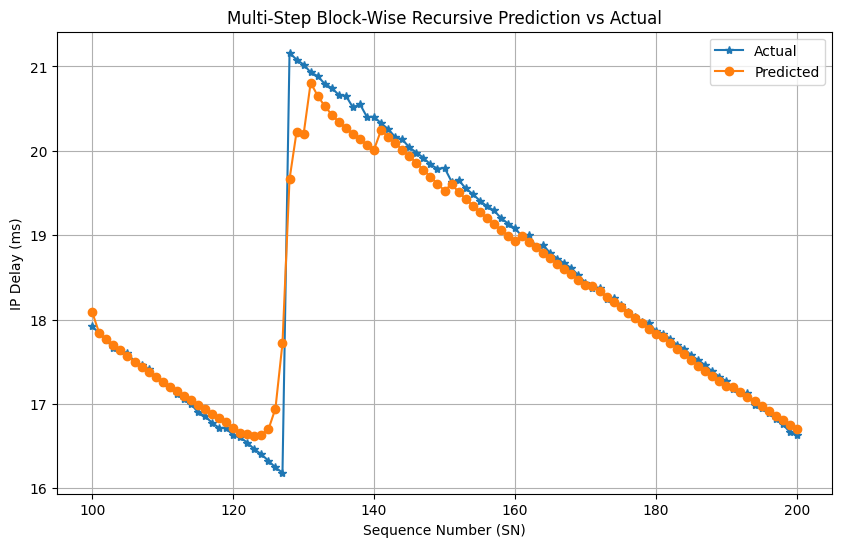

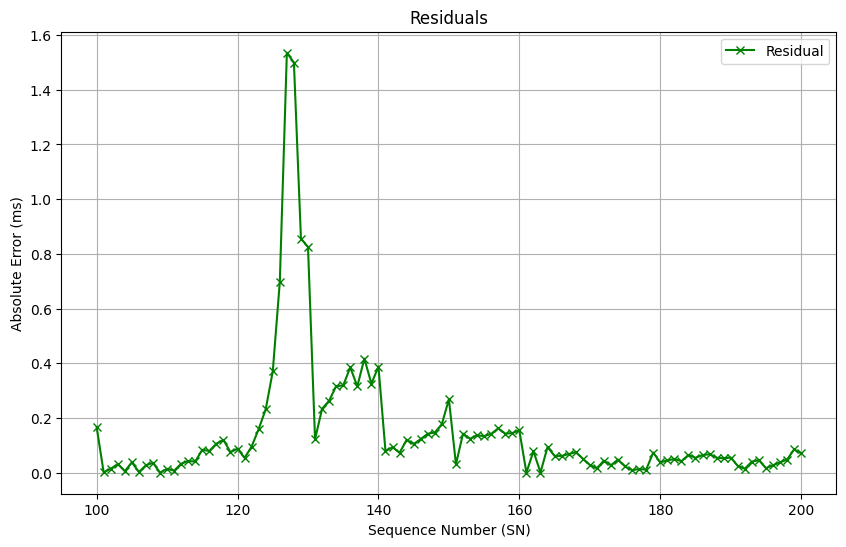

Residual Summary:
 count    3470.000000
mean        0.200877
std         0.393057
min         0.000069
25%         0.036142
50%         0.093945
75%         0.210823
max         4.112961
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Step 1: Load and Normalize Data
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# -------------------------
# Step 2: Sequence Creation
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Prepare test values
test_values = test_data['Normalized IP Delay'].values

# -------------------------
# Step 3: Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Step 4: Block-wise Multi-Step Recursive Prediction
# -------------------------
block_size = 10  # Predict 10 steps at a time
total_steps = len(test_values) - sequence_length

predictions = []
actuals = []

i = 0
while i + sequence_length + block_size <= len(test_values):
    input_sequence = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_predictions = []
    current_sequence = input_sequence.copy()

    # Step 1: Predict next 10 values recursively
    for _ in range(block_size):
        pred = model.predict(current_sequence.reshape(1, sequence_length, 1), verbose=0)
        block_predictions.append(pred[0][0])
        current_sequence = np.append(current_sequence[1:], [[pred[0][0]]], axis=0)

    predictions.extend(block_predictions)
    
    # Step 2: Store corresponding ground truth for comparison
    actual_block = test_values[i + sequence_length: i + sequence_length + block_size]
    actuals.extend(actual_block)

    # Step 3: Move to the next block (use actuals now as input)
    i += block_size

# -------------------------
# Step 5: Denormalize and Save Results
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

# Build DataFrame
result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# Optional filtering for a plot
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

# -------------------------
# Step 6: Plot and Save
# -------------------------
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Multi-Step Block-Wise Recursive Prediction vs Actual')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', marker='x', color='green')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals')
plt.legend()
plt.grid()
plt.show()

# Save results
result_df.to_csv('blockwise_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1013 - val_loss: 0.0142
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0134 - val_loss: 0.0107
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0112 - val_loss: 0.0095
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0091 - val_loss: 0.0077
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0085 - val_loss: 0.0064
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0073 - val_loss: 0.0052
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0054 - val_loss: 0.0047
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0055 - val_loss: 0.0040
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044 - val_loss: 0.0041
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0045 - val_loss: 0.0042
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0052 - val_loss: 0.0041
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.

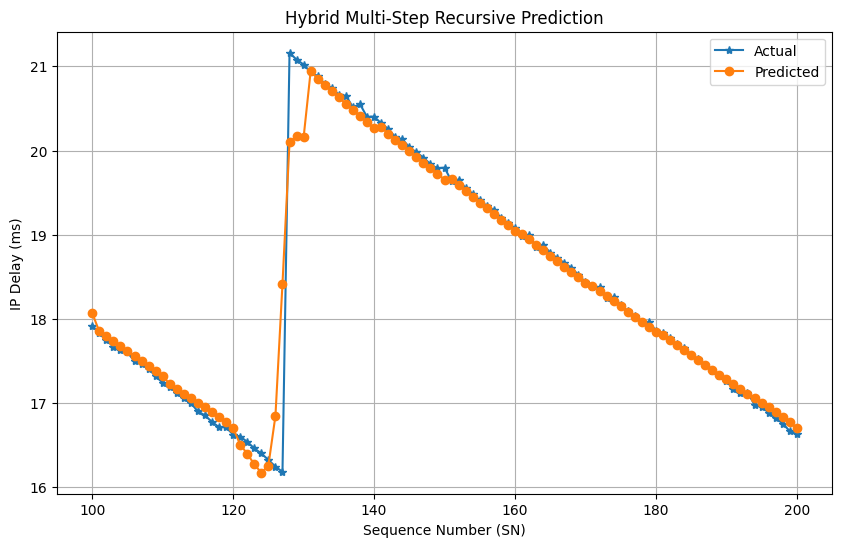

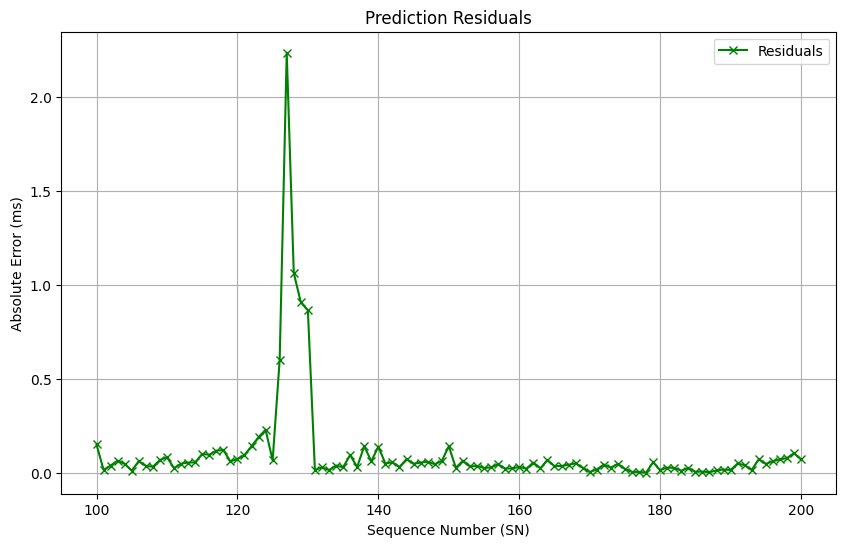

Residual Summary:
 count    3470.000000
mean        0.135936
std         0.377924
min         0.000119
25%         0.021787
50%         0.044976
75%         0.079544
max         3.940424
Name: Absolute Difference (ms), dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequencesaaa
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction_10.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


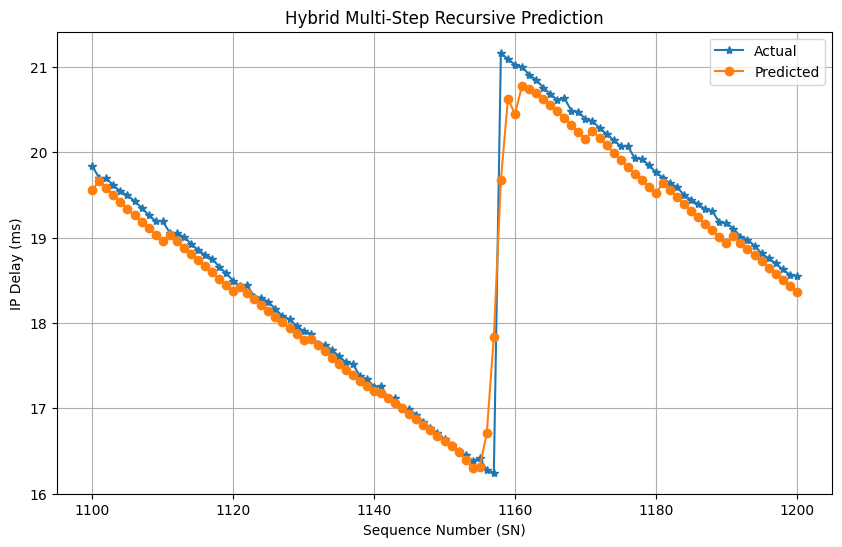

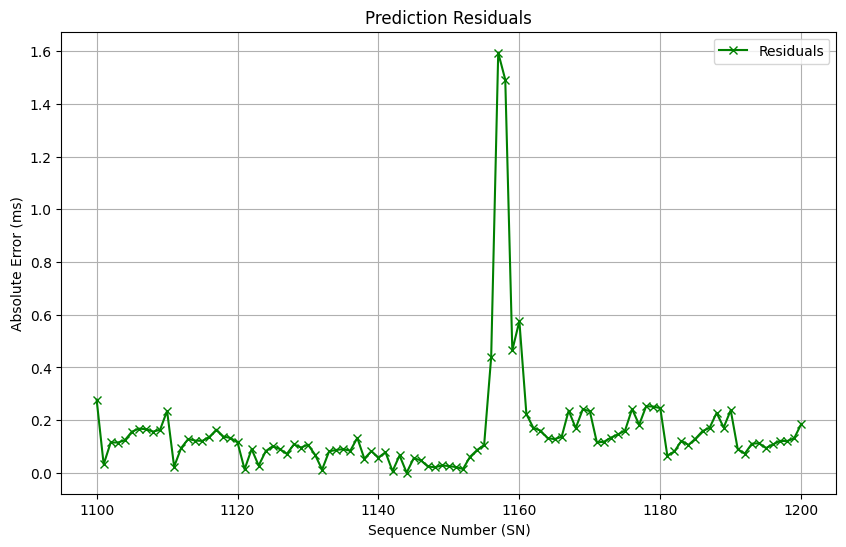

Residual Summary:
 count    3470.000000
mean        0.177898
std         0.315722
min         0.000183
25%         0.064419
50%         0.108479
75%         0.170793
max         3.296829
Name: Absolute Difference (ms), dtype: float64


In [11]:
filtered_df = result_df[(result_df['SN'] >= 1100) & (result_df['SN'] <= 1200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0464 - val_loss: 0.0115
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0104 - val_loss: 0.0061
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0080 - val_loss: 0.0107
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0058 - val_loss: 0.0052
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0066 - val_loss: 0.0040
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044 - val_loss: 0.0135
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0070 - val_loss: 0.0034
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0054 - val_loss: 0.0034
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0058 - val_loss: 0.0030
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0

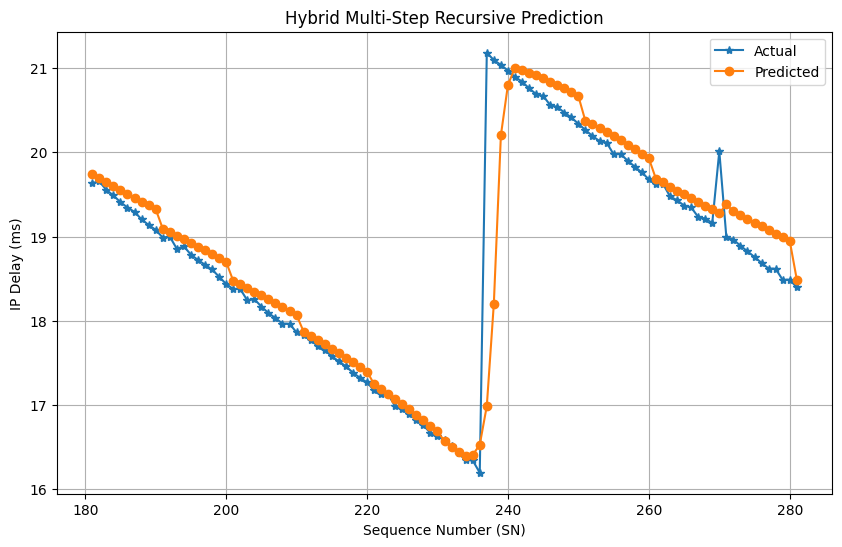

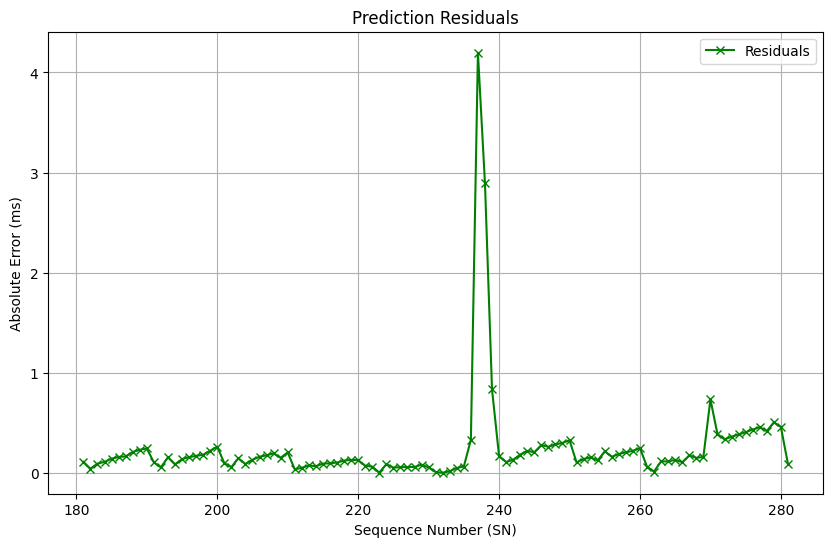

Residual Summary:
 count    3320.000000
mean        0.222925
std         0.491977
min         0.000083
25%         0.083370
50%         0.140001
75%         0.202259
max         4.509040
Name: Absolute Difference (ms), dtype: float64


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------

# Set starting index (anywhere within the test dataset)
start_index = 150  # <-- CHANGE this to start from a different point

# Ensure it's a valid starting point
test_values = test_data['Normalized IP Delay'].values
if start_index + sequence_length >= len(test_values):
    raise ValueError("Start index is too close to the end of the dataset for given sequence length.")

future_steps = 10
predictions = []
actuals = []
sn_list = []

i = start_index

while i + sequence_length + future_steps <= len(test_values):
    # Use actual values to build the input sequence
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    block_preds = []
    current_seq = input_seq.copy()

    # Predict next 'future_steps' values recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)

    # Collect actual values
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Track sequence numbers (1-based)
    sn_block = list(range(i + sequence_length + 1, i + sequence_length + future_steps + 1))
    sn_list.extend(sn_block)

    # Shift to next block
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': sn_list,
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[
    (result_df['SN'] >= sn_list[0]) & (result_df['SN'] <= sn_list[0] + 100)
]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# -------------------------
# Save Results
# -------------------------
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0803 - val_loss: 0.0101
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0106 - val_loss: 0.0109
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0072 - val_loss: 0.0058
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0069 - val_loss: 0.0047
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0060 - val_loss: 0.0035
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0056 - val_loss: 0.0062
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0063 - val_loss: 0.0051
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0058 - val_loss: 0.0080
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0078 - val_loss: 0.0044
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step -

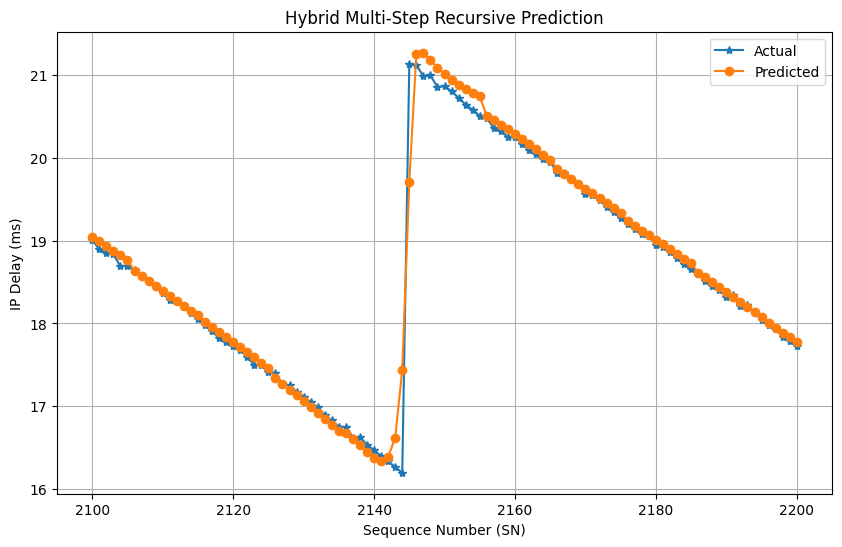

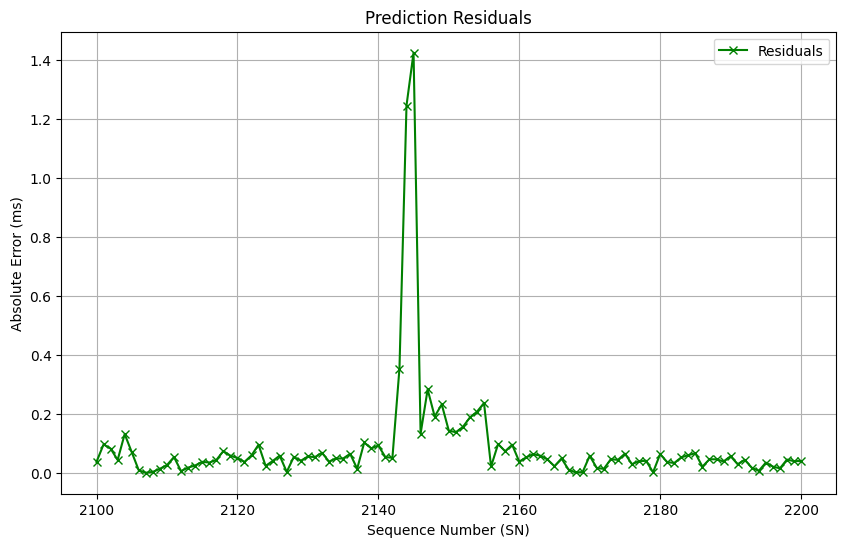

Residual Summary:
 count    1730.000000
mean        0.104477
std         0.301062
min         0.000020
25%         0.021332
50%         0.044923
75%         0.079679
max         3.822077
Name: Absolute Difference (ms), dtype: float64


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction Starting from Middle
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

# Calculate the middle starting index, adjusted for sequence length
total_length = len(test_values)
middle_index = max(0, total_length // 2 - sequence_length // 2)  # Ensure non-negative
i = middle_index

while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(middle_index + sequence_length + 1, middle_index + sequence_length + len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 2100) & (result_df['SN'] <= 2200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0548 - val_loss: 0.0101
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0096 - val_loss: 0.0058
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0075 - val_loss: 0.0035
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0068 - val_loss: 0.0047
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0049 - val_loss: 0.0069
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0070 - val_loss: 0.0060
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0068 - val_loss: 0.0071
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0055 - val_loss: 0.0059
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0058 - val_loss: 0.0033
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0059 - val_loss: 0.0048
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0051 - val_loss: 0.0037
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━

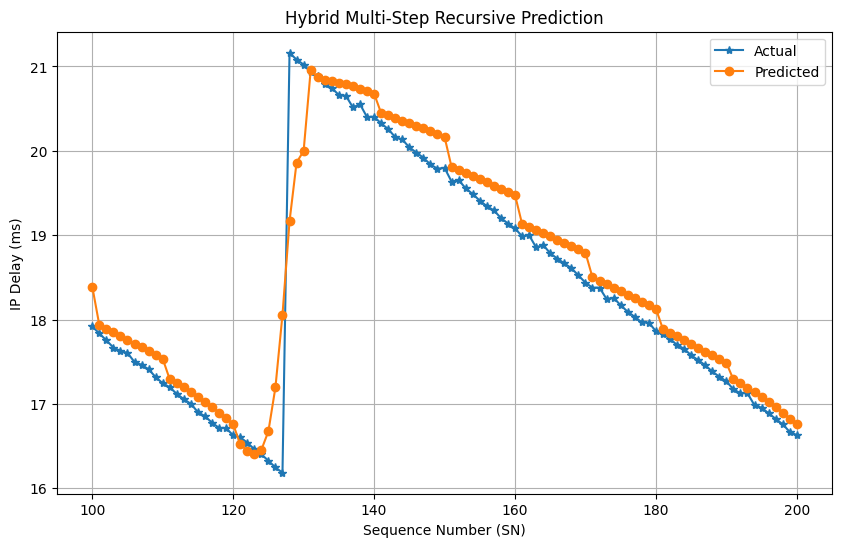

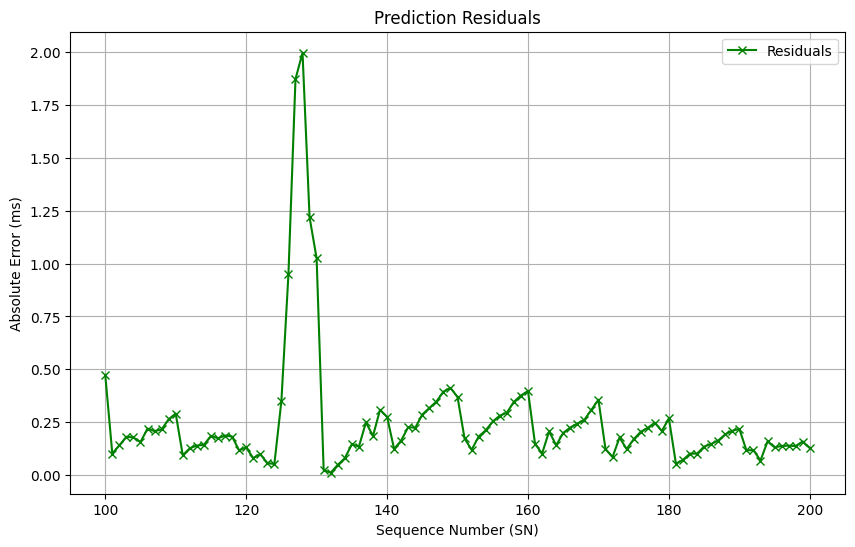

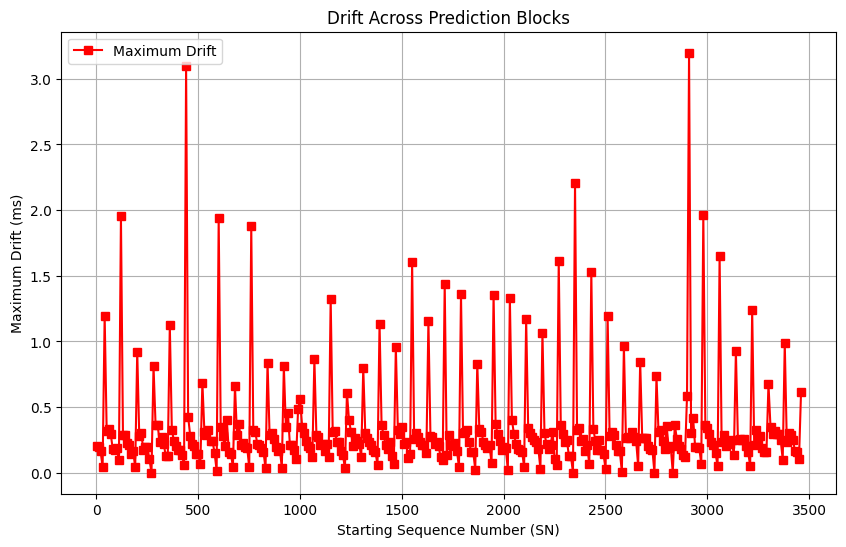

Residual Summary:
 count    3470.000000
mean        0.295016
std         0.409972
min         0.000310
25%         0.127422
50%         0.201863
75%         0.294637
max         3.730802
Name: Absolute Difference (ms), dtype: float64

Drift Summary:
 count    347.000000
mean       0.345679
std        0.408645
min        0.000000
25%        0.171765
50%        0.233501
75%        0.309319
max        3.198206
Name: Maximum Drift (ms), dtype: float64


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction with Drift Calculation
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []
drift_values = []  # To store maximum drift per block

i = 0
block_start_sn = 1
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    block_actuals = []
    current_seq = input_seq.copy()
    block_diff = []  # Track differences within this block

    # Step 2: Predict next 10 steps recursively
    for j in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)
        
        # Get corresponding actual value
        actual_val = test_values[i + sequence_length + j]
        block_actuals.append(actual_val)
        diff = abs((next_val * (max_test - min_test)) + min_test - (actual_val * (max_test - min_test)) + min_test)
        block_diff.append(diff)

    # Calculate drift as the maximum difference increase from the first step
    if block_diff:
        initial_diff = block_diff[0]
        max_drift = max(block_diff) - initial_diff if block_diff else 0
        drift_values.append((block_start_sn, max_drift))
        print(f"Block starting at SN {block_start_sn}: Maximum drift = {max_drift:.2f} ms")

    predictions.extend(block_preds)
    actuals.extend(block_actuals)

    # Step 3: Move to the next block
    i += future_steps
    block_start_sn += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Plot Drift
drift_df = pd.DataFrame(drift_values, columns=['Start SN', 'Maximum Drift (ms)'])
plt.figure(figsize=(10, 6))
plt.plot(drift_df['Start SN'], drift_df['Maximum Drift (ms)'], label='Maximum Drift', color='red', marker='s')
plt.xlabel('Starting Sequence Number (SN)')
plt.ylabel('Maximum Drift (ms)')
plt.title('Drift Across Prediction Blocks')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())
print("\nDrift Summary:\n", drift_df['Maximum Drift (ms)'].describe())

ENHANCED HYBRID LSTM MODEL

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0345 - val_loss: 0.0045
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0037 - val_loss: 0.0020
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0026 - val_loss: 0.0034
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0037
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/ste

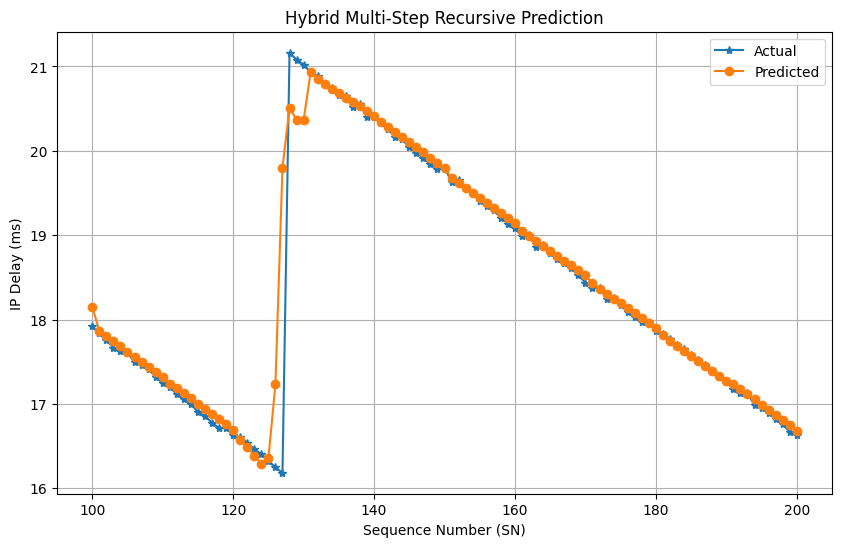

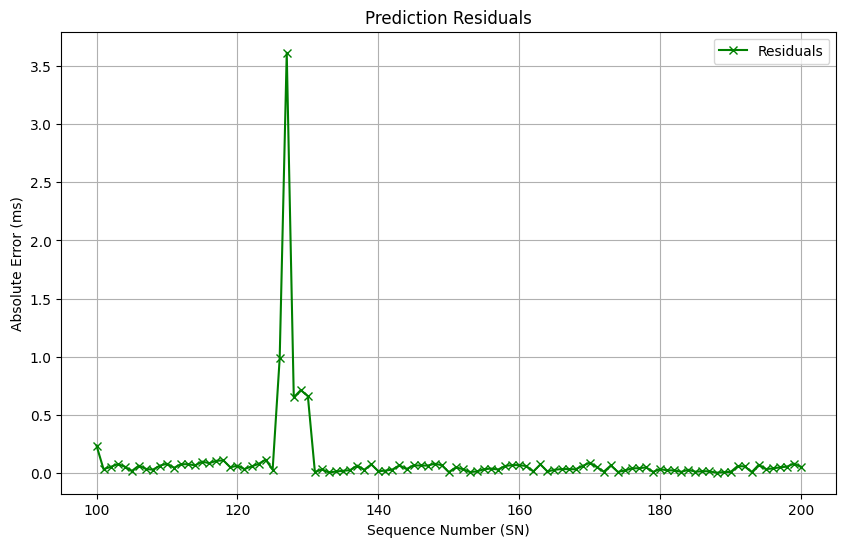

Residual Summary:
 count    3470.000000
mean        0.107955
std         0.295818
min         0.000014
25%         0.017421
50%         0.037018
75%         0.064071
max         3.894803
Name: Absolute Difference (ms), dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())



Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0279 - val_loss: 0.0052
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0049 - val_loss: 0.0039
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0036 - val_loss: 0.0023
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0036 - val_loss: 0.0022
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0032 - val_loss: 0.0019
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0022 - val_loss: 0.0028
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/ste

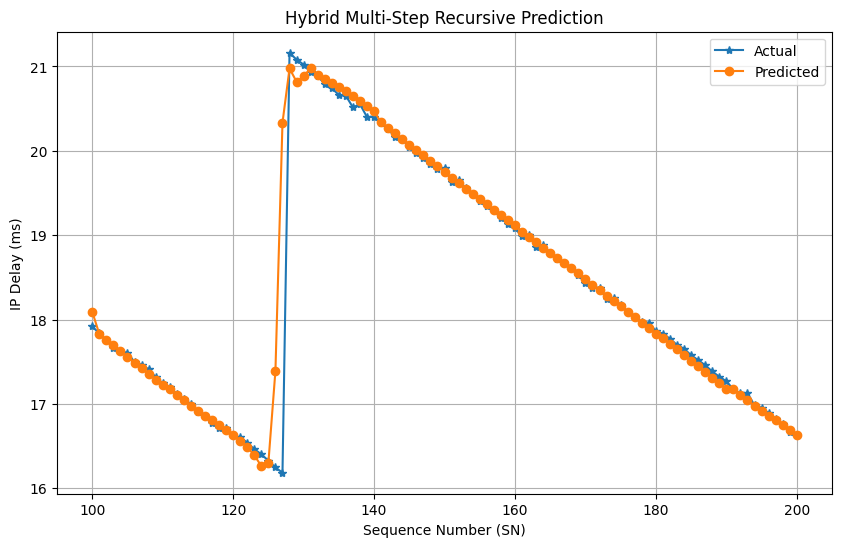

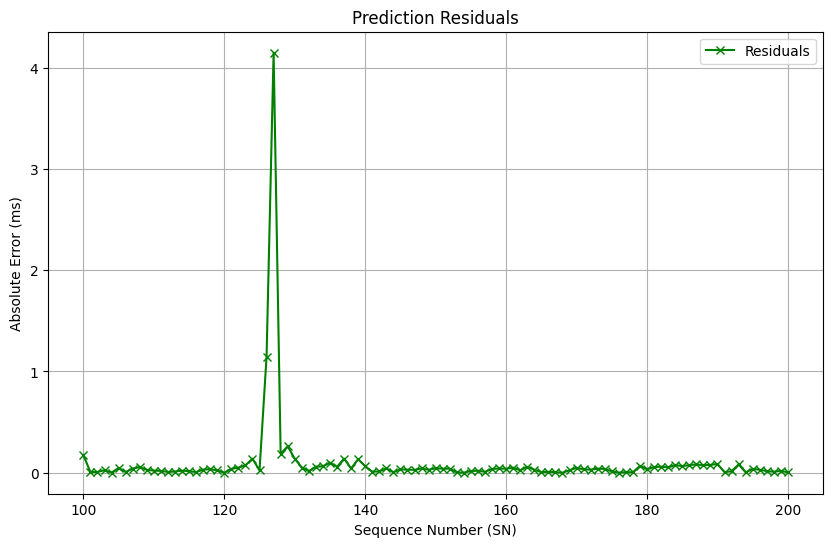

Residual Summary:
 count    3470.000000
mean        0.087117
std         0.300887
min         0.000047
25%         0.014263
50%         0.032452
75%         0.061959
max         4.761278
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('enhanced_hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())



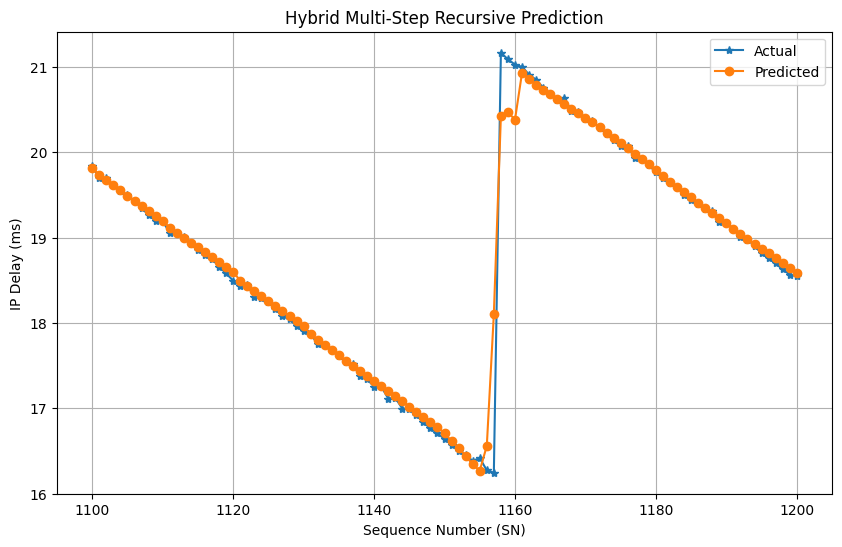

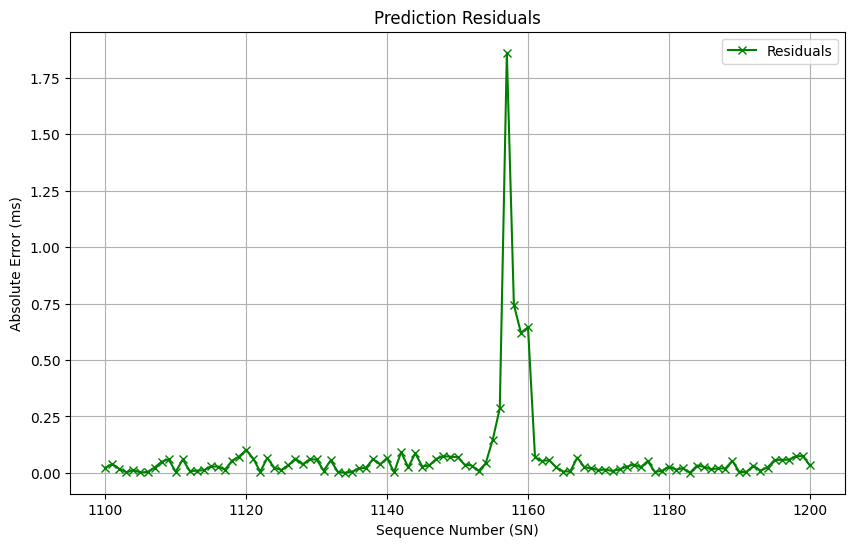

Residual Summary:
 count    3470.000000
mean        0.107955
std         0.295818
min         0.000014
25%         0.017421
50%         0.037018
75%         0.064071
max         3.894803
Name: Absolute Difference (ms), dtype: float64


In [13]:
filtered_df = result_df[(result_df['SN'] >= 1100) & (result_df['SN'] <= 1200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()


print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0925 - val_loss: 0.0149
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0138 - val_loss: 0.0101
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0092 - val_loss: 0.0080
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0079 - val_loss: 0.0070
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0094 - val_loss: 0.0079
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0065 - val_loss: 0.0056
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - val_loss: 0.0050
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0048 - val_loss: 0.0036
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0048 - val_loss: 0.0095
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0087 - val_loss: 0.0042
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - l

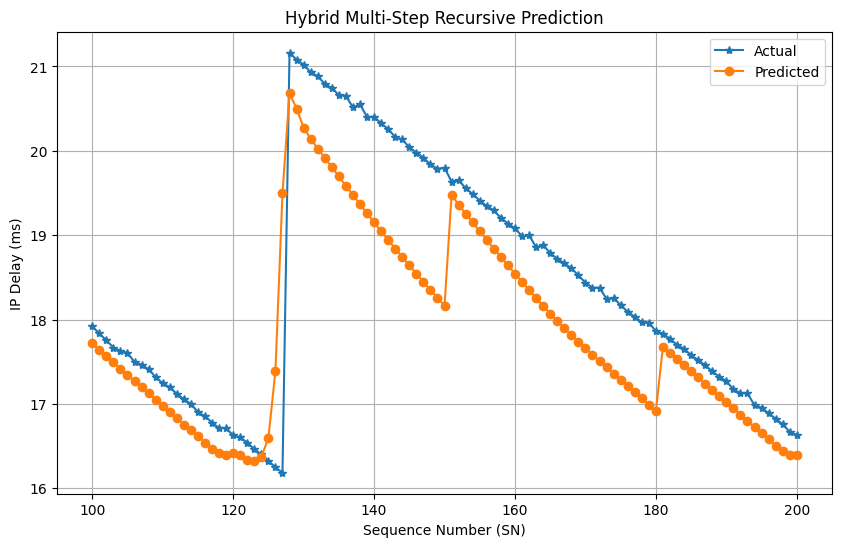

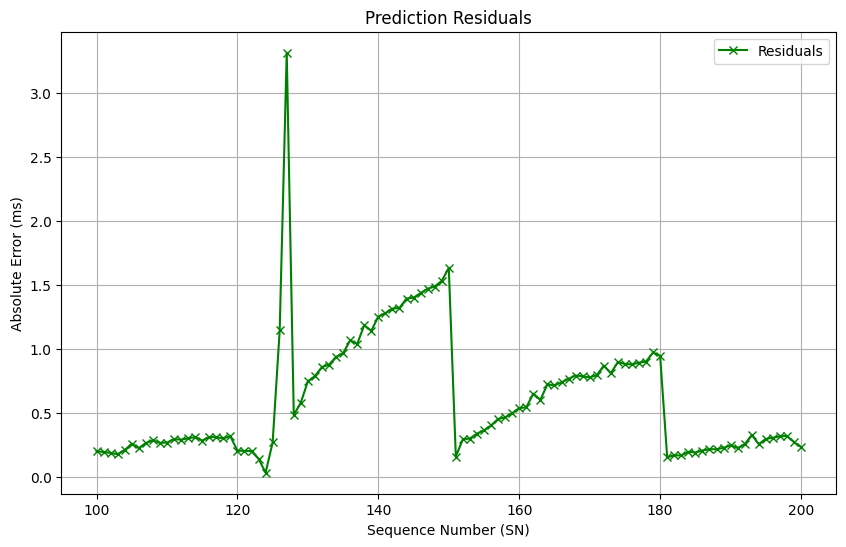

Residual Summary:
 count    3450.000000
mean        0.716019
std         0.534906
min         0.000197
25%         0.304698
50%         0.613799
75%         1.036719
max         4.136634
Name: Absolute Difference (ms), dtype: float64


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0942 - val_loss: 0.0126
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0113 - val_loss: 0.0071
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0077 - val_loss: 0.0053
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0064 - val_loss: 0.0067
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0056 - val_loss: 0.0047
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0051 - val_loss: 0.0109
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0060 - val_loss: 0.0067
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0061 - val_loss: 0.0054
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0048 - val_loss: 0.0083
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0054 - val_loss: 0.0058
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/ste

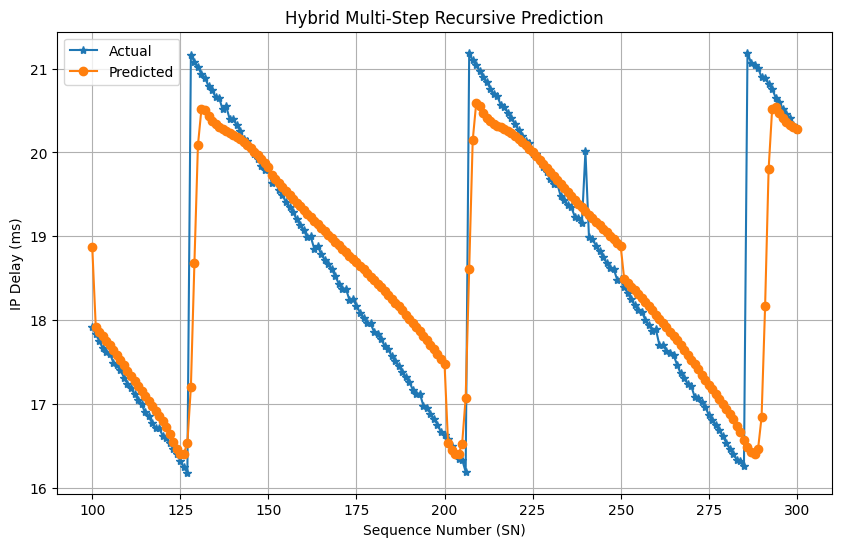

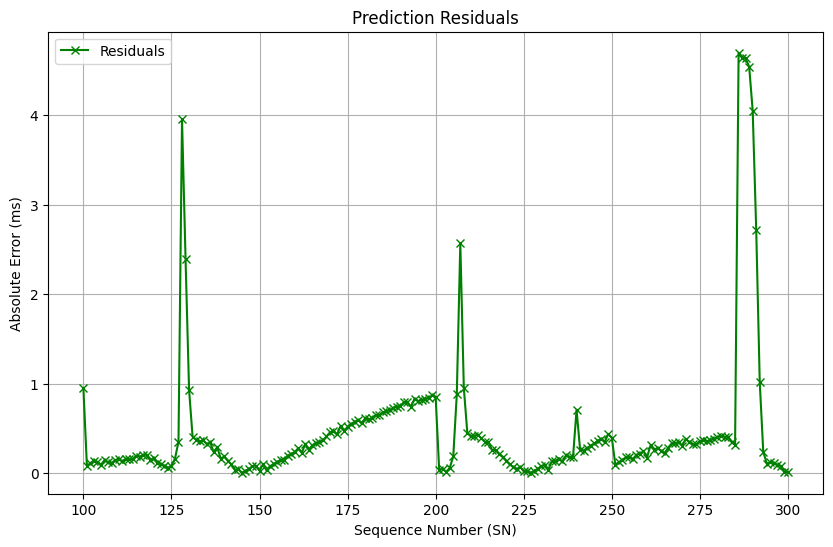

Residual Summary:
 count    3450.000000
mean        0.485956
std         0.723188
min         0.000176
25%         0.142851
50%         0.335847
75%         0.569914
max         4.815430
Name: Absolute Difference (ms), dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 50
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 300)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0807 - val_loss: 0.0146
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0126 - val_loss: 0.0090
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0090 - val_loss: 0.0086
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0081 - val_loss: 0.0069
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0066 - val_loss: 0.0060
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - val_loss: 0.0106
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0064 - val_loss: 0.0041
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0062 - val_loss: 0.0043
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0053 - val_loss: 0.0034
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0056 - val_loss: 0.0044
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.

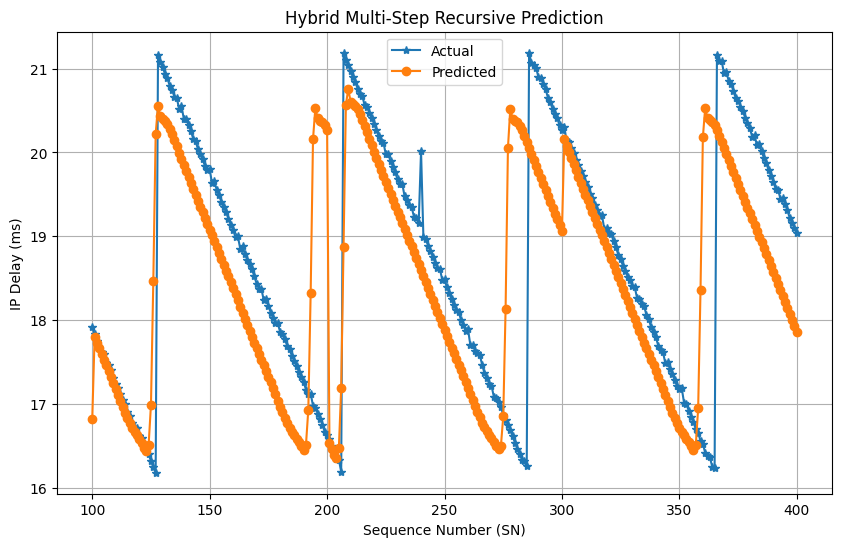

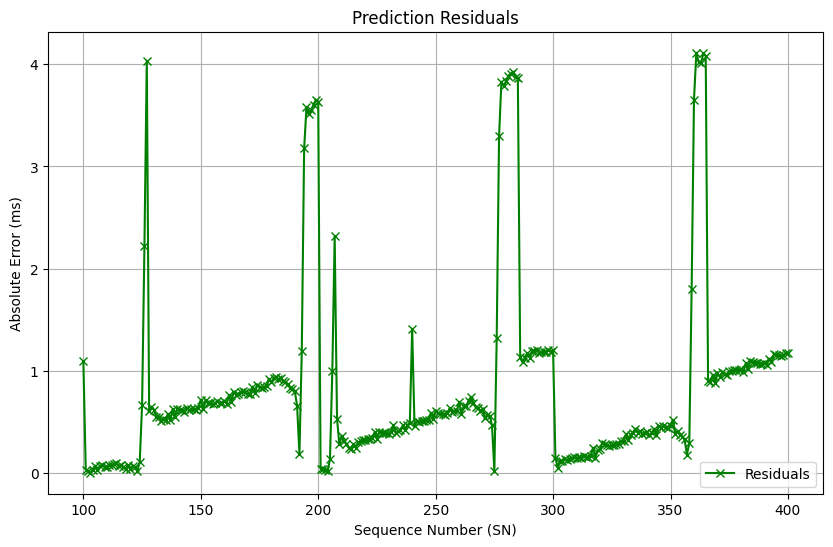

Residual Summary:
 count    3400.000000
mean        0.776253
std         0.871079
min         0.001073
25%         0.248130
50%         0.605107
75%         0.930398
max         4.334879
Name: Absolute Difference (ms), dtype: float64


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 100
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    # Using actual values for the next input
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 400)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Save
result_df.to_csv('hybrid_recursive_prediction.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0879 - val_loss: 0.0257
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0219 - val_loss: 0.0132
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0152 - val_loss: 0.0114
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0114 - val_loss: 0.0102
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0103 - val_loss: 0.0088
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0089 - val_loss: 0.0086
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0102 - val_loss: 0.0101
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095 - val_loss: 0.0073
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0073 - val_loss: 0.0075
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0065 - val_loss: 0.0064
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0052 - val_loss: 0.0044
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0048 - val

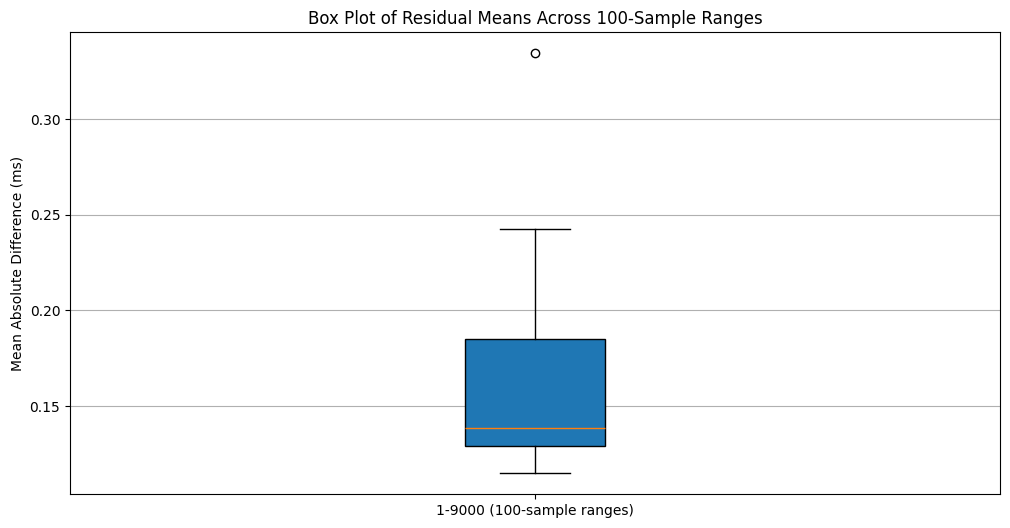

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       0.156315
std    2612.470096  2612.470096       0.038674
min       1.000000   100.000000       0.114883
25%    2226.000000  2325.000000       0.129258
50%    4451.000000  4550.000000       0.138333
75%    6676.000000  6775.000000       0.184905
max    8901.000000  9000.000000       0.334327


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Residual Means for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(residual_means, patch_artist=True)
plt.title('Box Plot of Residual Means Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.1607 - val_loss: 0.0337
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0276 - val_loss: 0.0160
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0164 - val_loss: 0.0130
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0141 - val_loss: 0.0117
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0118 - val_loss: 0.0101
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0087 - val_loss: 0.0092
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0089 - val_loss: 0.0085
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0077 - val_loss: 0.0065
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0093 - val_loss: 0.0061
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0071 - val_loss: 0.0088

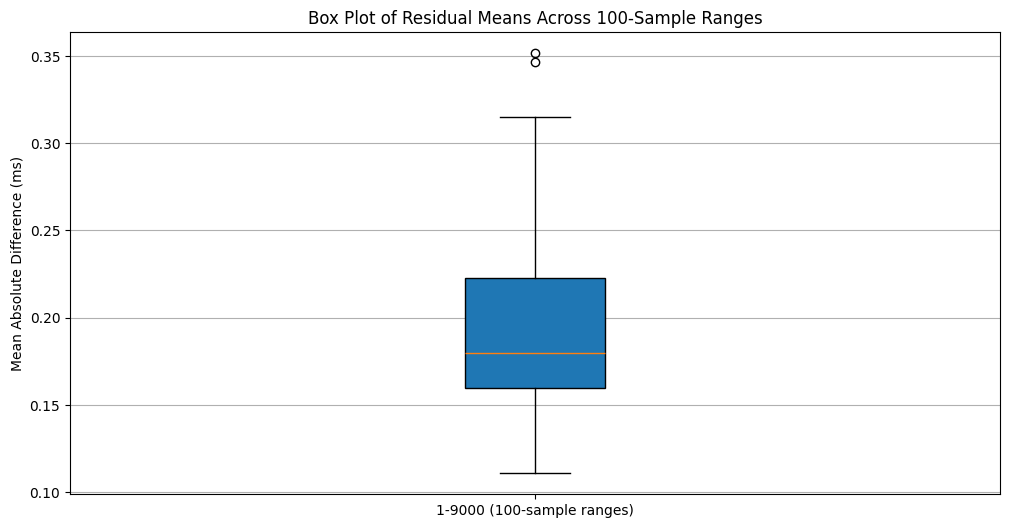

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       0.196134
std    2612.470096  2612.470096       0.050204
min       1.000000   100.000000       0.110839
25%    2226.000000  2325.000000       0.159720
50%    4451.000000  4550.000000       0.180032
75%    6676.000000  6775.000000       0.222504
max    8901.000000  9000.000000       0.351552


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Residual Means for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(residual_means, patch_artist=True)
plt.title('Box Plot of Residual Means Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1569 - val_loss: 0.0284
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0264 - val_loss: 0.0168
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0147 - val_loss: 0.0135
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0134 - val_loss: 0.0129
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0121 - val_loss: 0.0102
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0090 - val_loss: 0.0101
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0108 - val_loss: 0.0102
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0095 - val_loss: 0.0086
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0080 - val_loss: 0.0079
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0090 - val_loss: 0.0090
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0085 - val_loss: 0.0084
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0091 - val_l

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\244857597.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])


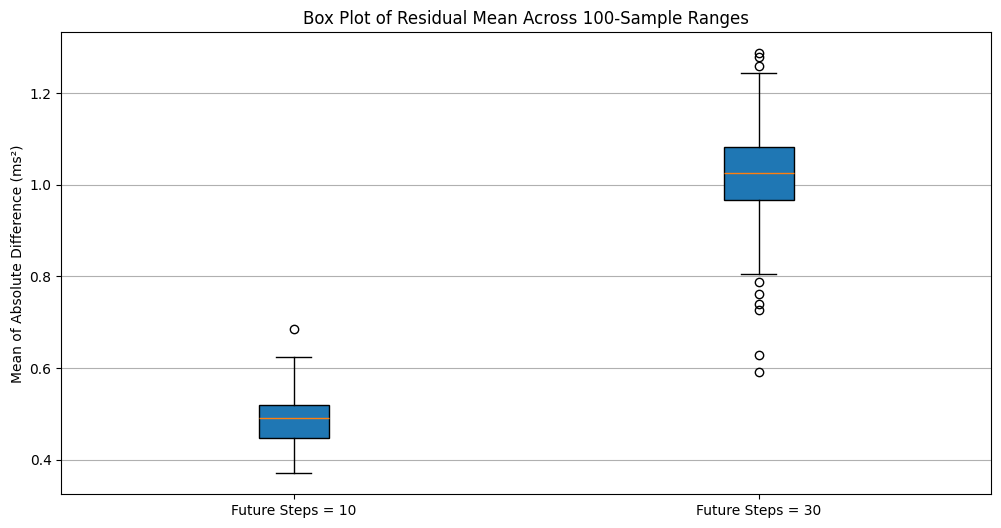

Residual Variances Summary (Future Steps = 10):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.486851
std    2612.470096  2612.470096           0.057539
min       1.000000   100.000000           0.370440
25%    2226.000000  2325.000000           0.446862
50%    4451.000000  4550.000000           0.490841
75%    6676.000000  6775.000000           0.519840
max    8901.000000  9000.000000           0.684993

Residual Variances Summary (Future Steps = 30):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           1.016487
std    2612.470096  2612.470096           0.132791
min       1.000000   100.000000           0.590928
25%    2226.000000  2325.000000           0.966295
50%    4451.000000  4550.000000           1.024754
75%    6676.000000  6775.000000           1.082168
max    8901.000000  9000.000000   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Function to Perform Prediction and Calculate Residual Mean
# -------------------------
def calculate_residual_mean(test_values, future_steps, sequence_length, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    result_df = pd.DataFrame({
        'SN': range(1, len(actuals_denorm) + 1),
        'Actual IP Delay (ms)': actuals_denorm,
        'Predicted IP Delay (ms)': preds_denorm,
        'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
    })

    range_size = 100
    num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
    residual_means = []

    for range_idx in range(num_ranges):
        start_idx = range_idx * range_size
        end_idx = (range_idx + 1) * range_size
        range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
        if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
            residual_mean = range_df['Absolute Difference (ms)'].mean()
            residual_means.append(residual_mean)
            
    return residual_means

# -------------------------
# Calculate Residual Variances for Both Cases
# -------------------------
test_values = test_data['Normalized IP Delay'].values

mean_fs10 = calculate_residual_mean(test_values, future_steps=10, sequence_length=sequence_length, min_test=min_test, max_test=max_test)
mean_fs30 = calculate_residual_mean(test_values, future_steps=30, sequence_length=sequence_length, min_test=min_test, max_test=max_test)

# Combine variances into a list of lists for box plot
all_variances = [mean_fs10, mean_fs30]

# -------------------------
# Plot Box Plot of Residual Means for Both Cases
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])
plt.title('Box Plot of Residual Mean Across 100-Sample Ranges')
plt.ylabel('Mean of Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_fs10 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': mean_fs10
})
result_df_ranges_fs30 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': mean_fs30
})
result_df_ranges_fs10.to_csv('residual_mean_fs10_by_range.csv', index=False)
result_df_ranges_fs30.to_csv('residual_mean_fs30_by_range.csv', index=False)
print("Residual Variances Summary (Future Steps = 10):\n", result_df_ranges_fs10.describe())
print("\nResidual Variances Summary (Future Steps = 30):\n", result_df_ranges_fs30.describe())

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1309 - val_loss: 0.0293
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0232 - val_loss: 0.0189
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0152 - val_loss: 0.0106
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0127 - val_loss: 0.0140
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0100 - val_loss: 0.0095
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0093 - val_loss: 0.0083
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0063 - val_loss: 0.0109
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0083 - val_loss: 0.0063
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0073 - val_loss: 0.0063
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0054 - val_loss: 0.0056
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0053 - val_loss: 0.0097
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0

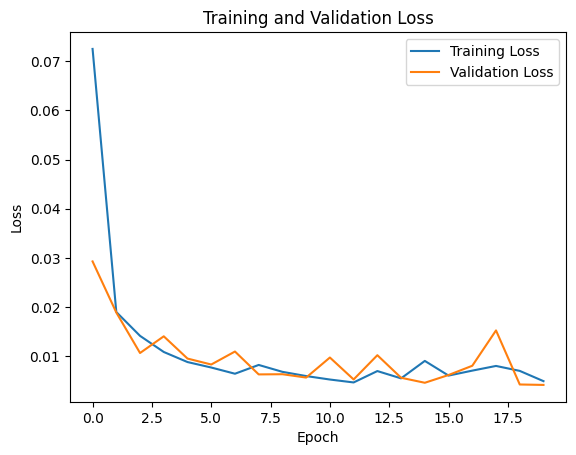

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\3417975951.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_variances, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])


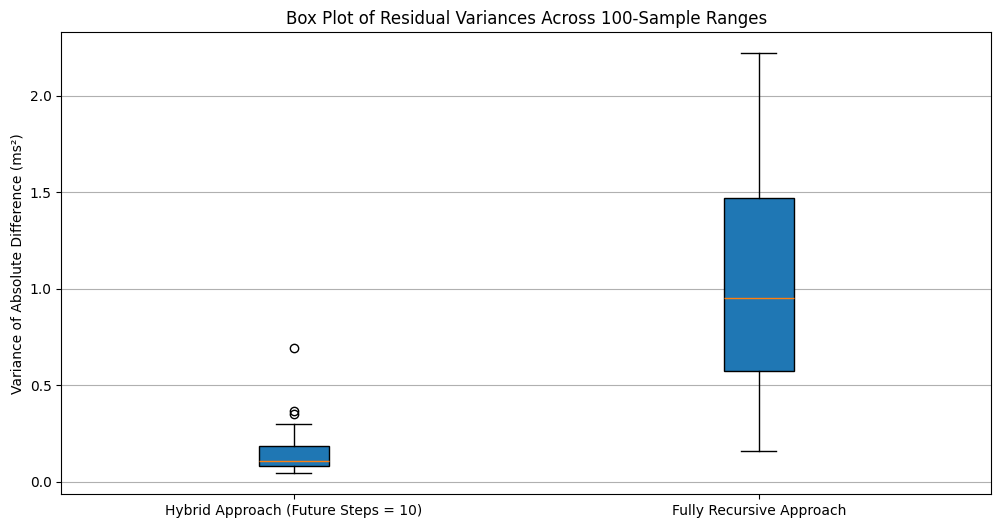

Residual Variances Summary (Hybrid):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.139363
std    2612.470096  2612.470096           0.095594
min       1.000000   100.000000           0.043039
25%    2226.000000  2325.000000           0.078741
50%    4451.000000  4550.000000           0.109103
75%    6676.000000  6775.000000           0.182682
max    8901.000000  9000.000000           0.690697

Residual Variances Summary (Fully Recursive):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           1.037379
std    2612.470096  2612.470096           0.527384
min       1.000000   100.000000           0.160009
25%    2226.000000  2325.000000           0.573473
50%    4451.000000  4550.000000           0.953757
75%    6676.000000  6775.000000           1.469720
max    8901.000000  9000.000000           2.219

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

# Normalize training data
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# Normalize test data using training min and max for consistency
min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -------------------------
# Prediction Functions
# -------------------------

# Fully Recursive Prediction Function
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Hybrid Prediction Function
def hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    return preds_denorm, actuals_denorm

# -------------------------
# Calculate Residual Variances for Both Approaches
# -------------------------
# Fully Recursive Approach
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

result_df_recursive = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_variances_recursive = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_recursive[(result_df_recursive['SN'] >= start_idx + 1) & (result_df_recursive['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) > 0:  # Ensure some data
        residual_variance = range_df['Absolute Difference (ms)'].var()
        residual_variances_recursive.append(residual_variance)

# Hybrid Approach
future_steps = 10
preds_hybrid_denorm, actuals_hybrid_denorm = hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test)

result_df_hybrid = pd.DataFrame({
    'SN': range(1, len(actuals_hybrid_denorm) + 1),
    'Actual IP Delay (ms)': actuals_hybrid_denorm,
    'Predicted IP Delay (ms)': preds_hybrid_denorm,
    'Absolute Difference (ms)': abs(actuals_hybrid_denorm - preds_hybrid_denorm)
})

residual_variances_hybrid = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_hybrid[(result_df_hybrid['SN'] >= start_idx + 1) & (result_df_hybrid['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_variance = range_df['Absolute Difference (ms)'].var()
        residual_variances_hybrid.append(residual_variance)

# -------------------------
# Plot Box Plot of Residual Variances for Both Approaches
# -------------------------
all_variances = [residual_variances_hybrid, residual_variances_recursive]
plt.figure(figsize=(12, 6))
plt.boxplot(all_variances, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])
plt.title('Box Plot of Residual Variances Across 100-Sample Ranges')
plt.ylabel('Variance of Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_hybrid = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Variance': residual_variances_hybrid
})
result_df_ranges_recursive = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Variance': residual_variances_recursive
})
result_df_ranges_hybrid.to_csv('residual_variances_hybrid_by_range.csv', index=False)
result_df_ranges_recursive.to_csv('residual_variances_recursive_by_range.csv', index=False)
print("Residual Variances Summary (Hybrid):\n", result_df_ranges_hybrid.describe())
print("\nResidual Variances Summary (Fully Recursive):\n", result_df_ranges_recursive.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0627 - val_loss: 0.0211
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0181 - val_loss: 0.0134
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0124 - val_loss: 0.0115
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0109 - val_loss: 0.0088
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0086 - val_loss: 0.0079
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0081 - val_loss: 0.0076
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076 - val_loss: 0.0060
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0080 - val_loss: 0.0075
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0072 - val_loss: 0.0058
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0076 - val_loss: 0.0063
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0055 - val_loss: 0.0045
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0060 - val_l

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\1595952498.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])


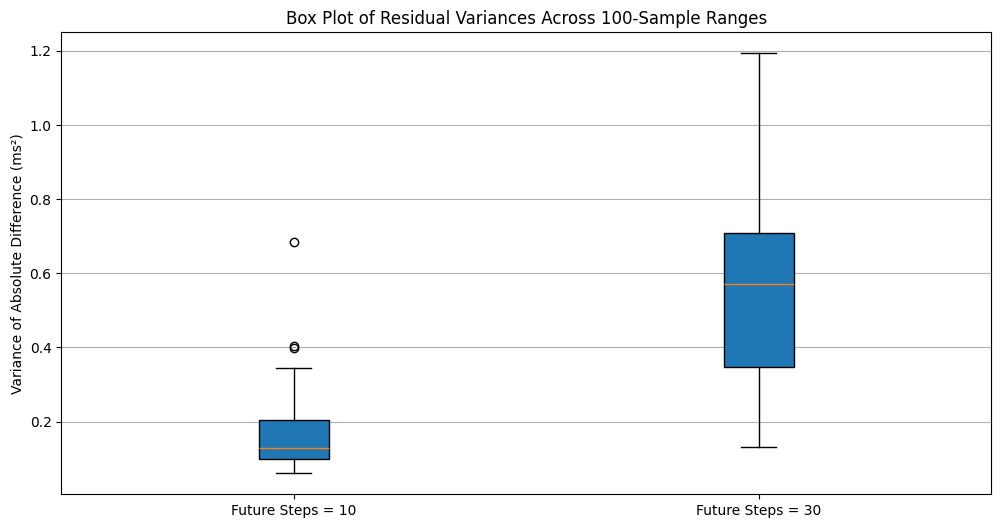

Residual Variances Summary (Future Steps = 10):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.165766
std    2612.470096  2612.470096           0.100254
min       1.000000   100.000000           0.060575
25%    2226.000000  2325.000000           0.099001
50%    4451.000000  4550.000000           0.128200
75%    6676.000000  6775.000000           0.204444
max    8901.000000  9000.000000           0.685429

Residual Variances Summary (Future Steps = 30):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.555636
std    2612.470096  2612.470096           0.246697
min       1.000000   100.000000           0.130384
25%    2226.000000  2325.000000           0.347521
50%    4451.000000  4550.000000           0.570640
75%    6676.000000  6775.000000           0.708328
max    8901.000000  9000.000000   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Function to Perform Prediction and Calculate Residual Variances
# -------------------------
def calculate_residual_variances(test_values, future_steps, sequence_length, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    result_df = pd.DataFrame({
        'SN': range(1, len(actuals_denorm) + 1),
        'Actual IP Delay (ms)': actuals_denorm,
        'Predicted IP Delay (ms)': preds_denorm,
        'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
    })

    range_size = 100
    num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
    residual_variances = []

    for range_idx in range(num_ranges):
        start_idx = range_idx * range_size
        end_idx = (range_idx + 1) * range_size
        range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
        if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
            residual_variance = range_df['Absolute Difference (ms)'].var()
            residual_variances.append(residual_variance)

    return residual_variances

# -------------------------
# Calculate Residual Variances for Both Cases
# -------------------------
test_values = test_data['Normalized IP Delay'].values

variances_fs10 = calculate_residual_variances(test_values, future_steps=10, sequence_length=sequence_length, min_test=min_test, max_test=max_test)
variances_fs30 = calculate_residual_variances(test_values, future_steps=30, sequence_length=sequence_length, min_test=min_test, max_test=max_test)

# Combine variances into a list of lists for box plot
all_variances = [variances_fs10, variances_fs30]

# -------------------------
# Plot Box Plot of Residual Variances for Both Cases
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])
plt.title('Box Plot of Residual Variances Across 100-Sample Ranges')
plt.ylabel('Variance of Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_fs10 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': variances_fs10
})
result_df_ranges_fs30 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': variances_fs30
})
result_df_ranges_fs10.to_csv('residual_variances_fs10_by_range.csv', index=False)
result_df_ranges_fs30.to_csv('residual_variances_fs30_by_range.csv', index=False)
print("Residual Variances Summary (Future Steps = 10):\n", result_df_ranges_fs10.describe())
print("\nResidual Variances Summary (Future Steps = 30):\n", result_df_ranges_fs30.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1028 - val_loss: 0.0226
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0179 - val_loss: 0.0135
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0126 - val_loss: 0.0167
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0112 - val_loss: 0.0086
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0110 - val_loss: 0.0091
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0077 - val_loss: 0.0113
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0091 - val_loss: 0.0058
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0062 - val_loss: 0.0082
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0070 - val_loss: 0.0059
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0070 - val_loss: 0.0052
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0054 - val_loss: 0.0055
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0050 - val_loss: 0.005

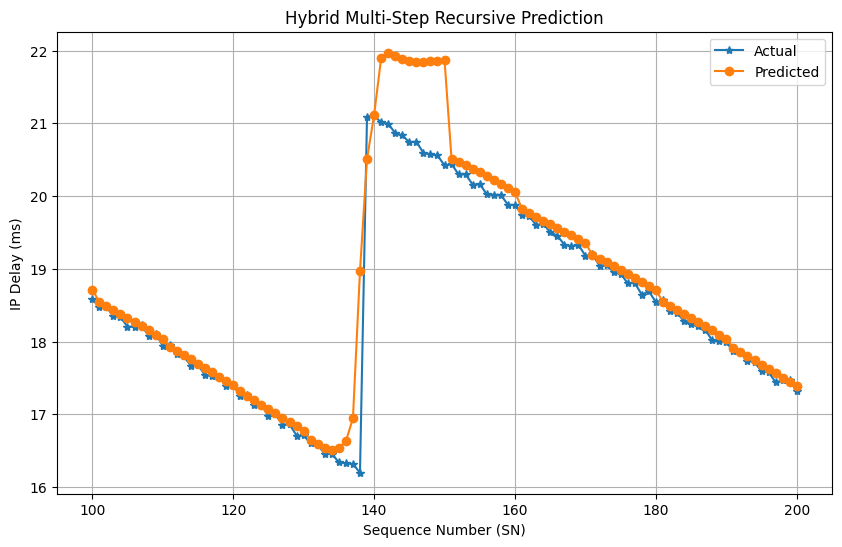

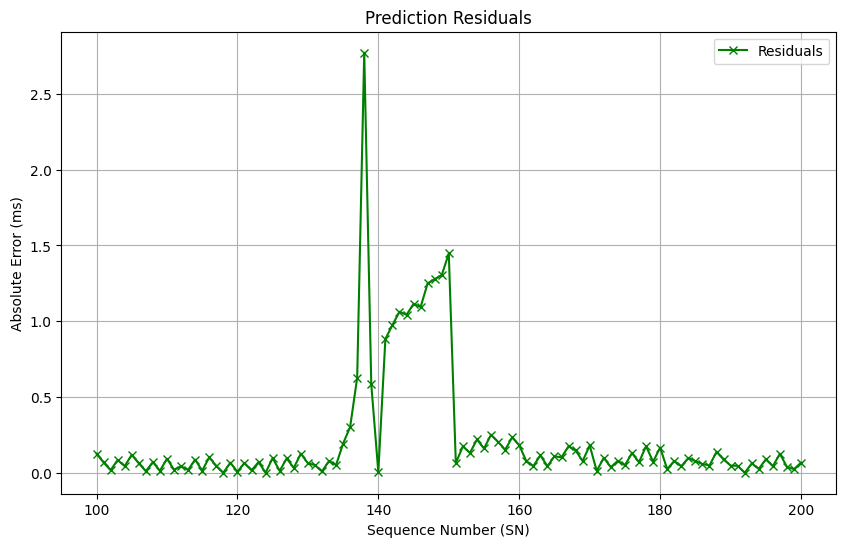

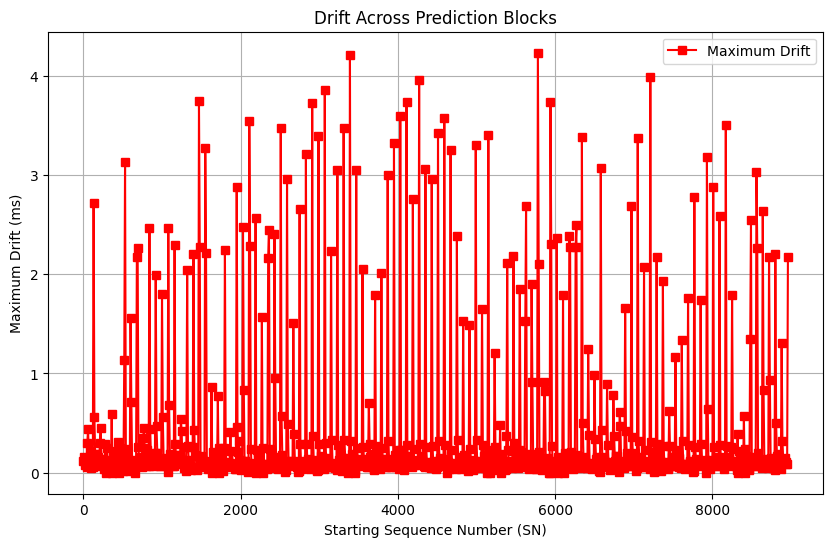

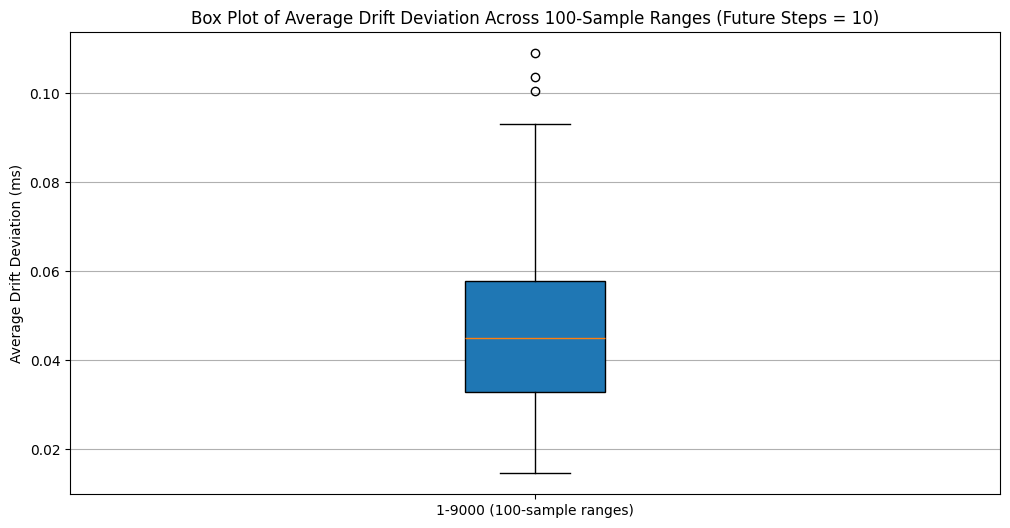

Average Drift Deviation Summary:
        Range_Start    Range_End  Average_Drift_Deviation
count    90.000000    90.000000                90.000000
mean   4451.000000  4550.000000                 0.046875
std    2612.470096  2612.470096                 0.021658
min       1.000000   100.000000                 0.014635
25%    2226.000000  2325.000000                 0.032979
50%    4451.000000  4550.000000                 0.045025
75%    6676.000000  6775.000000                 0.057722
max    8901.000000  9000.000000                 0.108916

Average Drift Deviation (Overall): 0.0469 ms
Residual Summary:
 count    8970.000000
mean        0.209601
std         0.409878
min         0.000038
25%         0.044426
50%         0.086539
75%         0.170268
max         4.548347
Name: Absolute Difference (ms), dtype: float64

Drift Summary:
 count    897.000000
mean       0.421933
std        0.826611
min        0.000000
25%        0.067211
50%        0.109662
75%        0.228017
max        4.229

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction with Drift Calculation
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []
drift_values = []  # To store maximum drift per block

i = 0
block_start_sn = 1
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    block_actuals = []
    current_seq = input_seq.copy()
    block_diff = []  # Track differences within this block

    # Step 2: Predict next 10 steps recursively
    for j in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)
        
        # Get corresponding actual value
        actual_val = test_values[i + sequence_length + j]
        block_actuals.append(actual_val)
        diff = abs((next_val * (max_test - min_test)) + min_test - (actual_val * (max_test - min_test)) + min_test)
        block_diff.append(diff)

    # Calculate drift as the maximum difference increase from the first step
    if block_diff:
        initial_diff = block_diff[0]
        max_drift = max(block_diff) - initial_diff if block_diff else 0
        drift_values.append((block_start_sn, max_drift))
        print(f"Block starting at SN {block_start_sn}: Maximum drift = {max_drift:.2f} ms")

    predictions.extend(block_preds)
    actuals.extend(block_actuals)

    # Step 3: Move to the next block
    i += future_steps
    block_start_sn += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Plot Drift
drift_df = pd.DataFrame(drift_values, columns=['Start SN', 'Maximum Drift (ms)'])
plt.figure(figsize=(10, 6))
plt.plot(drift_df['Start SN'], drift_df['Maximum Drift (ms)'], label='Maximum Drift', color='red', marker='s')
plt.xlabel('Starting Sequence Number (SN)')
plt.ylabel('Maximum Drift (ms)')
plt.title('Drift Across Prediction Blocks')
plt.legend()
plt.grid()
plt.show()

# -------------------------
# Calculate Average Drift Deviation for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
drift_deviations = []

for range_idx in range(num_ranges):
    start_sn = range_idx * range_size + 1
    end_sn = (range_idx + 1) * range_size
    range_drift_values = [drift[1] for drift in drift_values if start_sn <= drift[0] <= end_sn]
    
    if range_drift_values:
        average_drift_deviation = np.mean(range_drift_values) / (future_steps - 1)  # Divide by 9
    else:
        average_drift_deviation = np.nan  # No blocks in this range
    drift_deviations.append(average_drift_deviation)

# Remove NaN values if any
drift_deviations = [x for x in drift_deviations if not np.isnan(x)]

# -------------------------
# Plot Box Plot of Average Drift Deviations
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(drift_deviations, patch_artist=True)
plt.title('Box Plot of Average Drift Deviation Across 100-Sample Ranges (Future Steps = 10)')
plt.ylabel('Average Drift Deviation (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_drift = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Average_Drift_Deviation': drift_deviations
})
result_df_drift.to_csv('average_drift_deviation_by_range.csv', index=False)
print("Average Drift Deviation Summary:\n", result_df_drift.describe())

# -------------------------
# Calculate Average Drift Deviation
# -------------------------
max_drift_values = [drift[1] for drift in drift_values]  # Extract maximum drift values
average_drift_deviation = np.mean(max_drift_values) / (future_steps - 1) if max_drift_values else 0
print(f"\nAverage Drift Deviation (Overall): {average_drift_deviation:.4f} ms")

# Save
result_df.to_csv('hybrid_recursive_prediction_10.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())
print("\nDrift Summary:\n", drift_df['Maximum Drift (ms)'].describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1101 - val_loss: 0.0264
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0194 - val_loss: 0.0123
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0121 - val_loss: 0.0106
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0098 - val_loss: 0.0079
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0087 - val_loss: 0.0105
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0083 - val_loss: 0.0059
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0059 - val_loss: 0.0081
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080 - val_loss: 0.0163
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0081 - val_loss: 0.0065
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0056 - val_loss: 0.0060
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057 - val_lo

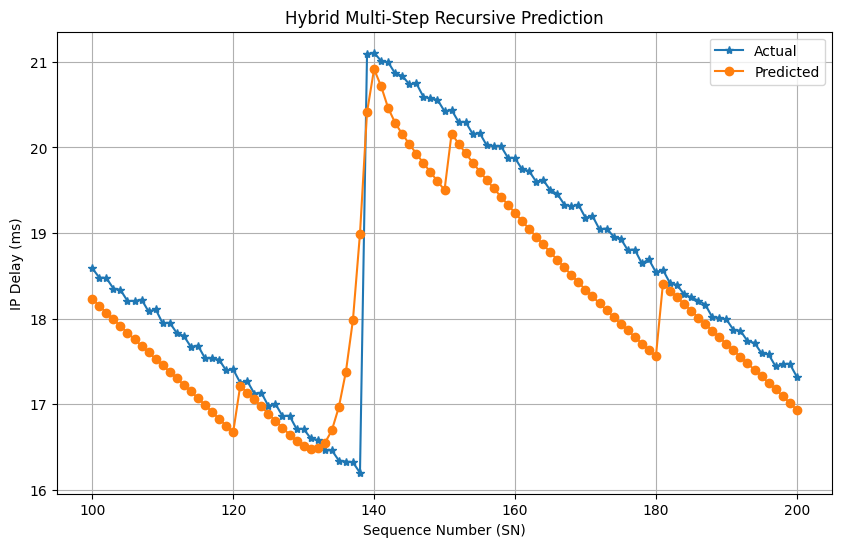

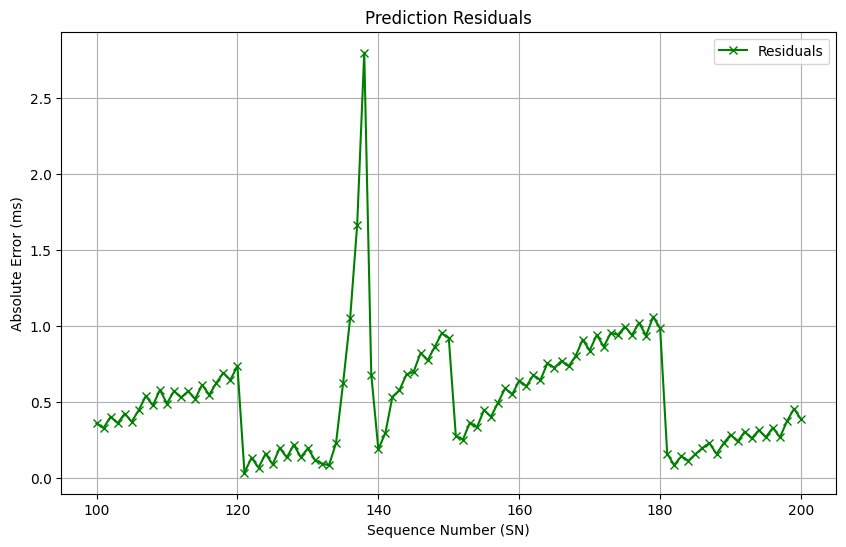

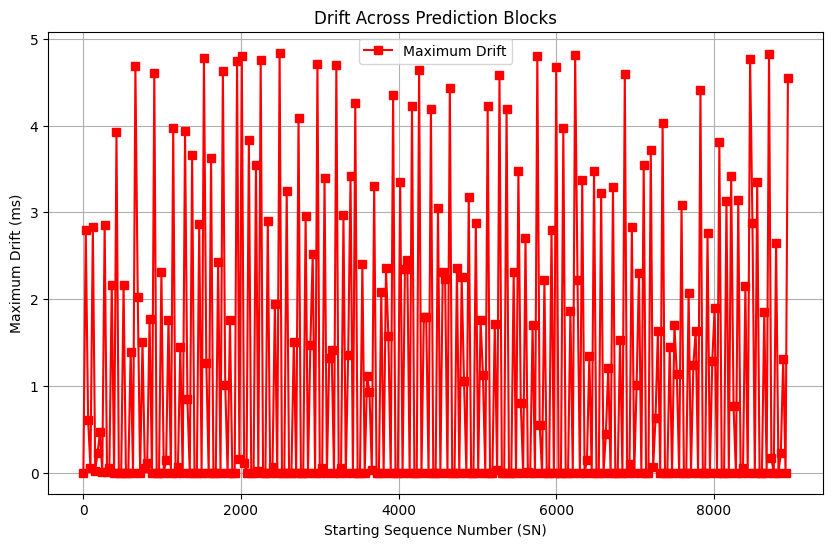

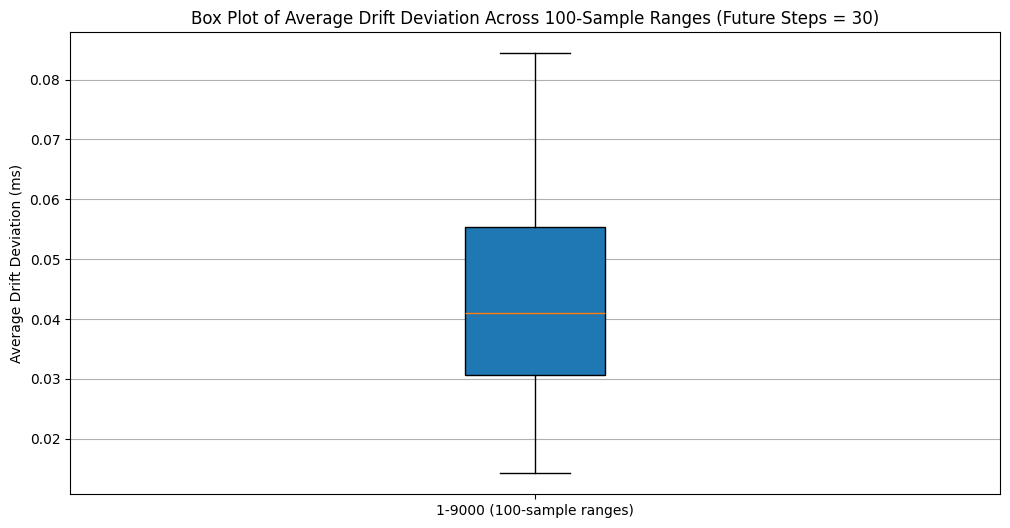

Average Drift Deviation Summary:
        Range_Start    Range_End  Average_Drift_Deviation
count    90.000000    90.000000                90.000000
mean   4451.000000  4550.000000                 0.043894
std    2612.470096  2612.470096                 0.017850
min       1.000000   100.000000                 0.014226
25%    2226.000000  2325.000000                 0.030594
50%    4451.000000  4550.000000                 0.040952
75%    6676.000000  6775.000000                 0.055334
max    8901.000000  9000.000000                 0.084406

Average Drift Deviation (Overall): 0.0440 ms
Residual Summary:
 count    8970.000000
mean        0.582756
std         0.504702
min         0.000292
25%         0.259856
50%         0.489137
75%         0.777920
max         4.716284
Name: Absolute Difference (ms), dtype: float64

Drift Summary:
 count    299.000000
mean       1.275823
std        1.606619
min        0.000000
25%        0.000000
50%        0.064882
75%        2.381932
max        4.839

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction with Drift Calculation
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []
drift_values = []  # To store maximum drift per block

i = 0
block_start_sn = 1
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    block_actuals = []
    current_seq = input_seq.copy()
    block_diff = []  # Track differences within this block

    # Step 2: Predict next 10 steps recursively
    for j in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)
        
        # Get corresponding actual value
        actual_val = test_values[i + sequence_length + j]
        block_actuals.append(actual_val)
        diff = abs((next_val * (max_test - min_test)) + min_test - (actual_val * (max_test - min_test)) + min_test)
        block_diff.append(diff)

    # Calculate drift as the maximum difference increase from the first step
    if block_diff:
        initial_diff = block_diff[0]
        max_drift = max(block_diff) - initial_diff if block_diff else 0
        drift_values.append((block_start_sn, max_drift))
        print(f"Block starting at SN {block_start_sn}: Maximum drift = {max_drift:.2f} ms")

    predictions.extend(block_preds)
    actuals.extend(block_actuals)

    # Step 3: Move to the next block
    i += future_steps
    block_start_sn += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Plot Results
# -------------------------
filtered_df = result_df[(result_df['SN'] >= 100) & (result_df['SN'] <= 200)]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Predicted IP Delay (ms)'], label='Predicted', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Hybrid Multi-Step Recursive Prediction')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residuals', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Prediction Residuals')
plt.legend()
plt.grid()
plt.show()

# Plot Drift
drift_df = pd.DataFrame(drift_values, columns=['Start SN', 'Maximum Drift (ms)'])
plt.figure(figsize=(10, 6))
plt.plot(drift_df['Start SN'], drift_df['Maximum Drift (ms)'], label='Maximum Drift', color='red', marker='s')
plt.xlabel('Starting Sequence Number (SN)')
plt.ylabel('Maximum Drift (ms)')
plt.title('Drift Across Prediction Blocks')
plt.legend()
plt.grid()
plt.show()

# -------------------------
# Calculate Average Drift Deviation for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
drift_deviations = []

for range_idx in range(num_ranges):
    start_sn = range_idx * range_size + 1
    end_sn = (range_idx + 1) * range_size
    range_drift_values = [drift[1] for drift in drift_values if start_sn <= drift[0] <= end_sn]
    
    if range_drift_values:
        average_drift_deviation = np.mean(range_drift_values) / (future_steps - 1)  # Divide by 29
    else:
        average_drift_deviation = np.nan  # No blocks in this range
    drift_deviations.append(average_drift_deviation)

# Remove NaN values if any
drift_deviations = [x for x in drift_deviations if not np.isnan(x)]

# -------------------------
# Plot Box Plot of Average Drift Deviations
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(drift_deviations, patch_artist=True)
plt.title('Box Plot of Average Drift Deviation Across 100-Sample Ranges (Future Steps = 30)')
plt.ylabel('Average Drift Deviation (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_drift = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Average_Drift_Deviation': drift_deviations
})
result_df_drift.to_csv('average_drift_deviation_by_range.csv', index=False)
print("Average Drift Deviation Summary:\n", result_df_drift.describe())

# -------------------------
# Calculate Average Drift Deviation
# -------------------------
max_drift_values = [drift[1] for drift in drift_values]  # Extract maximum drift values
average_drift_deviation = np.mean(max_drift_values) / (future_steps - 1) if max_drift_values else 0
print(f"\nAverage Drift Deviation (Overall): {average_drift_deviation:.4f} ms")

# Save
result_df.to_csv('hybrid_recursive_prediction_30.csv', index=False)
print("Residual Summary:\n", result_df['Absolute Difference (ms)'].describe())
print("\nDrift Summary:\n", drift_df['Maximum Drift (ms)'].describe())

In [ ]:
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)



Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0497 - val_loss: 0.0107
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0087 - val_loss: 0.0064
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0055 - val_loss: 0.0030
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.0055 - val_loss: 0.0089
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0047 - val_loss: 0.0070
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0034 - val_loss: 0.0023
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0038 - val_loss: 0.0032
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0026 - val_loss: 0.0029
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0027 - val_l

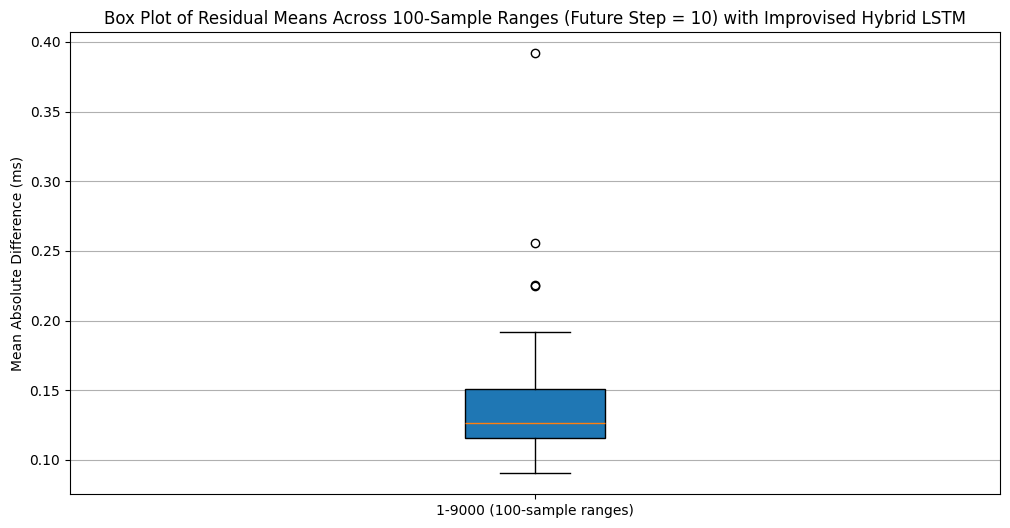

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       0.138724
std    2612.470096  2612.470096       0.041134
min       1.000000   100.000000       0.090322
25%    2226.000000  2325.000000       0.115678
50%    4451.000000  4550.000000       0.126485
75%    6676.000000  6775.000000       0.150647
max    8901.000000  9000.000000       0.391850


In [35]:
# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Residual Means for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(residual_means, patch_artist=True)
plt.title('Box Plot of Residual Means Across 100-Sample Ranges (Future Step = 10) with Improvised Hybrid LSTM')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means
})
result_df_ranges.to_csv('residual_means_by_range_improvised_10.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

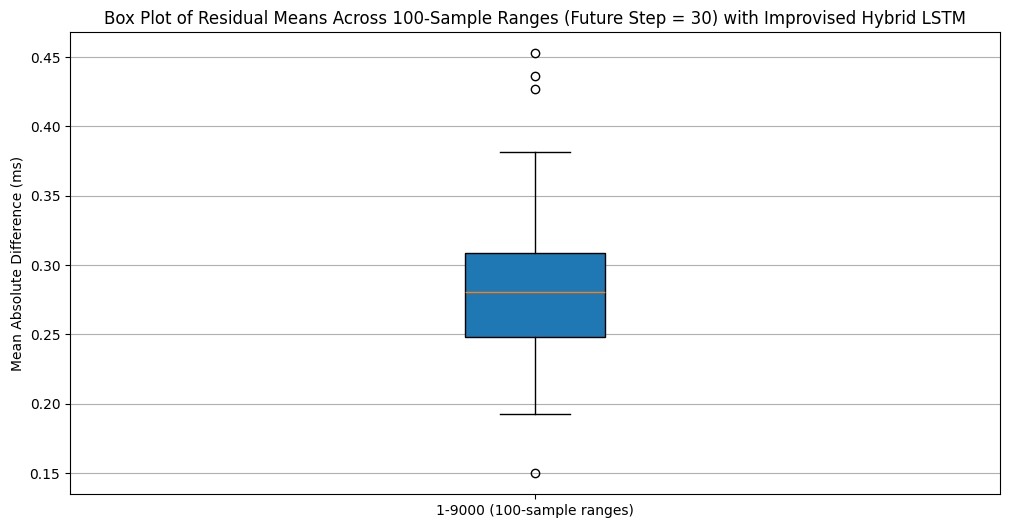

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       0.283511
std    2612.470096  2612.470096       0.052159
min       1.000000   100.000000       0.149863
25%    2226.000000  2325.000000       0.248070
50%    4451.000000  4550.000000       0.280518
75%    6676.000000  6775.000000       0.309054
max    8901.000000  9000.000000       0.452738


In [40]:
# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Residual Means for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(residual_means, patch_artist=True)
plt.title('Box Plot of Residual Means Across 100-Sample Ranges (Future Step = 30) with Improvised Hybrid LSTM')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means
})
result_df_ranges.to_csv('residual_means_by_range_improvised_30.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0513 - val_loss: 0.0113
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0099 - val_loss: 0.0073
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0072 - val_loss: 0.0051
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0041 - val_loss: 0.0026
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0038 - val_loss: 0.0023
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\724319224.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])


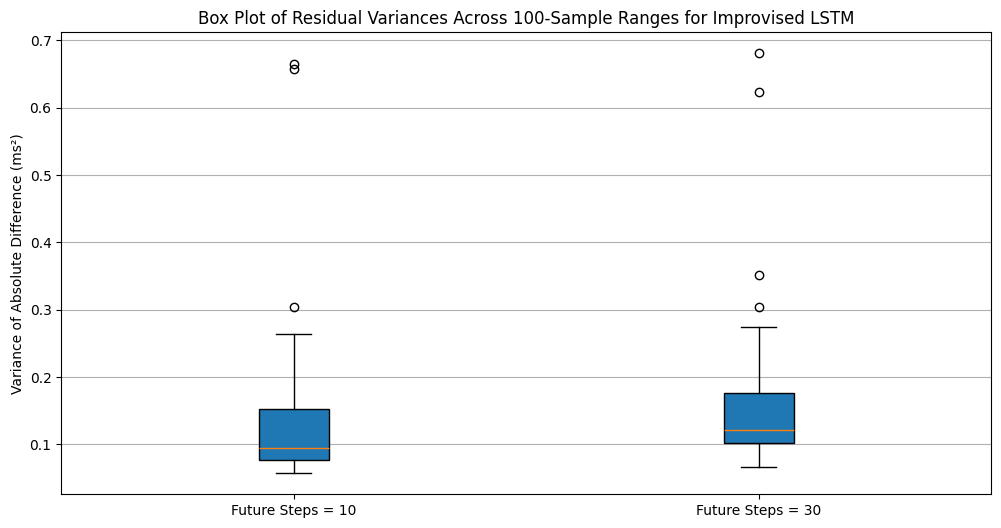

Residual Variances Summary (Future Steps = 10):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.126194
std    2612.470096  2612.470096           0.095283
min       1.000000   100.000000           0.056995
25%    2226.000000  2325.000000           0.077211
50%    4451.000000  4550.000000           0.094145
75%    6676.000000  6775.000000           0.152862
max    8901.000000  9000.000000           0.664074

Residual Variances Summary (Future Steps = 30):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.152198
std    2612.470096  2612.470096           0.093290
min       1.000000   100.000000           0.066967
25%    2226.000000  2325.000000           0.102293
50%    4451.000000  4550.000000           0.121723
75%    6676.000000  6775.000000           0.176285
max    8901.000000  9000.000000   

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
# -------------------------
# Function to Perform Prediction and Calculate Residual Variances
# -------------------------
def calculate_residual_variances(test_values, future_steps, sequence_length, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    result_df = pd.DataFrame({
        'SN': range(1, len(actuals_denorm) + 1),
        'Actual IP Delay (ms)': actuals_denorm,
        'Predicted IP Delay (ms)': preds_denorm,
        'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
    })

    range_size = 100
    num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
    residual_variances = []

    for range_idx in range(num_ranges):
        start_idx = range_idx * range_size
        end_idx = (range_idx + 1) * range_size
        range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
        if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
            residual_variance = range_df['Absolute Difference (ms)'].var()
            residual_variances.append(residual_variance)

    return residual_variances

# -------------------------
# Calculate Residual Variances for Both Cases
# -------------------------
test_values = test_data['Normalized IP Delay'].values

variances_fs10 = calculate_residual_variances(test_values, future_steps=10, sequence_length=sequence_length, min_test=min_test, max_test=max_test)
variances_fs30 = calculate_residual_variances(test_values, future_steps=30, sequence_length=sequence_length, min_test=min_test, max_test=max_test)

# Combine variances into a list of lists for box plot
all_variances = [variances_fs10, variances_fs30]

# -------------------------
# Plot Box Plot of Residual Variances for Both Cases
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(all_variances, patch_artist=True, labels=['Future Steps = 10', 'Future Steps = 30'])
plt.title('Box Plot of Residual Variances Across 100-Sample Ranges for Improvised LSTM')
plt.ylabel('Variance of Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_fs10 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': variances_fs10
})
result_df_ranges_fs30 = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(len(test_values) // 100)],
    'Range_End': [(i + 1) * 100 for i in range(len(test_values) // 100)],
    'Residual_Variance': variances_fs30
})
result_df_ranges_fs10.to_csv('residual_improvised_variances_fs10_by_range.csv', index=False)
result_df_ranges_fs30.to_csv('residual_improvised_variances_fs30_by_range.csv', index=False)
print("Residual Variances Summary (Future Steps = 10):\n", result_df_ranges_fs10.describe())
print("\nResidual Variances Summary (Future Steps = 30):\n", result_df_ranges_fs30.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1258 - val_loss: 0.0224
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0195 - val_loss: 0.0123
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0116 - val_loss: 0.0097
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0094 - val_loss: 0.0166
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0104 - val_loss: 0.0064
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0069 - val_loss: 0.0087
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0064 - val_loss: 0.0078
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0091 - val_loss: 0.0065
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0078 - val_loss: 0.0045
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0075 - val_loss: 0.0068
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0059
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0069 - val_loss: 0.0056

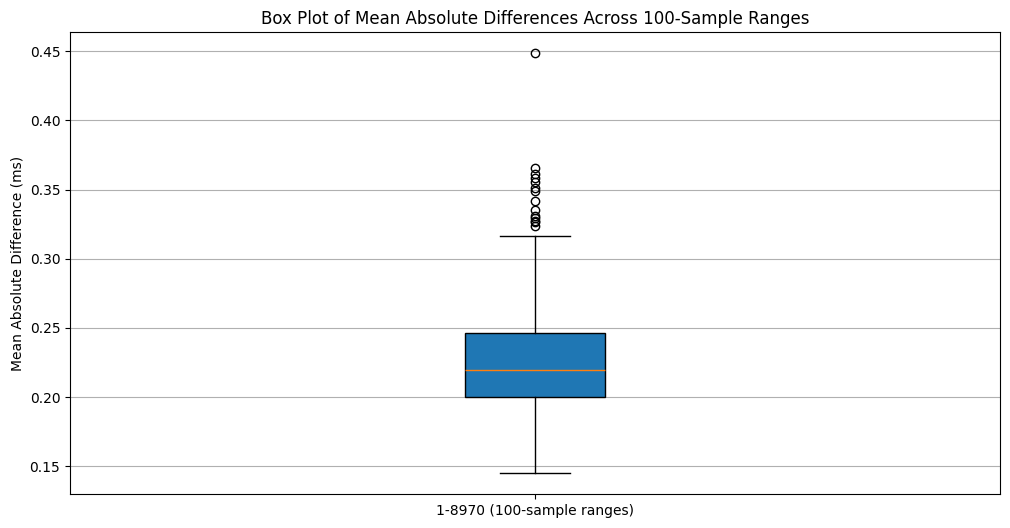

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    89.000000    89.000000      89.000000
mean   4401.000000  4500.000000       0.235180
std    2583.602137  2583.602137       0.062235
min       1.000000   100.000000       0.144988
25%    2201.000000  2300.000000       0.199930
50%    4401.000000  4500.000000       0.219603
75%    6601.000000  6700.000000       0.246658
max    8801.000000  8900.000000       0.448432


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Statistics for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(result_df) // range_size  # Adjusted to match prediction length
range_starts = [i * range_size + 1 for i in range(num_ranges)]
range_ends = [(i + 1) * range_size for i in range(num_ranges)]

mean_absolute_diff_range = []
quantile_90_absolute_diff_range = []
variance_absolute_diff_range = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        mean_absolute_diff_range.append(range_df['Absolute Difference (ms)'].mean())
        quantile_90_absolute_diff_range.append(range_df['Absolute Difference (ms)'].quantile(0.90))
        variance_absolute_diff_range.append(range_df['Absolute Difference (ms)'].var())

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Mean Absolute Difference (ms)': mean_absolute_diff_range
})
mean_df.to_csv('mean_hybrid_range.csv', index=False)

quantile_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    '90th Quantile Absolute Difference (ms)': quantile_90_absolute_diff_range
})
quantile_df.to_csv('90thquantile_hybrid_range.csv', index=False)

variance_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Variance Absolute Difference (ms²)': variance_absolute_diff_range
})
variance_df.to_csv('variance_hybrid_range.csv', index=False)

print("Range-Based Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(mean_absolute_diff_range, patch_artist=True)
plt.title('Box Plot of Mean Absolute Differences Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], [f'1-{len(result_df)} (100-sample ranges)'])  # Updated to reflect actual data length
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Residual_Mean': mean_absolute_diff_range  # Using mean as the representative statistic for the range
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0830 - val_loss: 0.0270
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0235 - val_loss: 0.0158
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0160 - val_loss: 0.0135
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0138 - val_loss: 0.0114
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0103 - val_loss: 0.0092
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0083 - val_loss: 0.0089
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0089 - val_loss: 0.0073
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - val_loss: 0.0093
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0084 - val_loss: 0.0065
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0067 - val_loss: 0.0056
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0058 - val_loss: 0.007

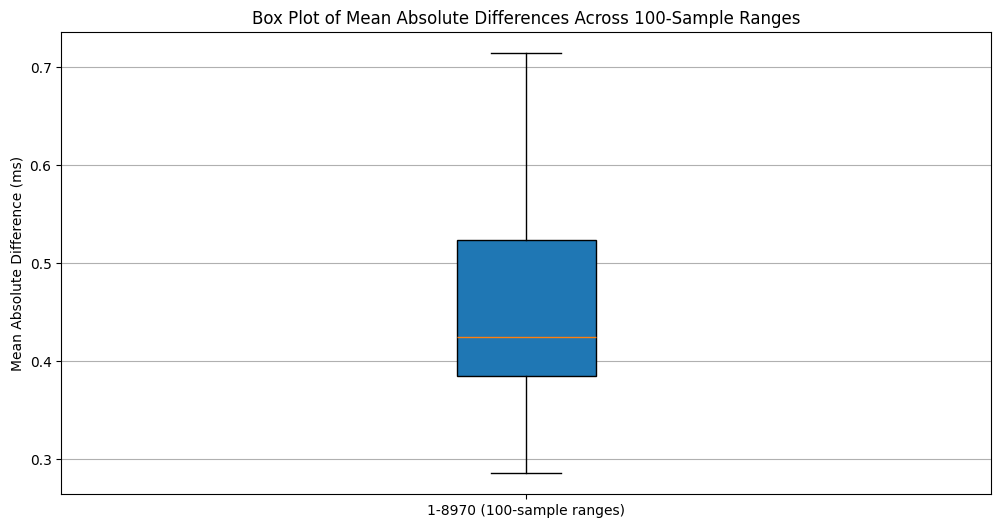

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    89.000000    89.000000      89.000000
mean   4401.000000  4500.000000       0.447304
std    2583.602137  2583.602137       0.096120
min       1.000000   100.000000       0.285576
25%    2201.000000  2300.000000       0.384453
50%    4401.000000  4500.000000       0.424273
75%    6601.000000  6700.000000       0.523487
max    8801.000000  8900.000000       0.714407


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 30
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Statistics for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(result_df) // range_size  # Adjusted to match prediction length
range_starts = [i * range_size + 1 for i in range(num_ranges)]
range_ends = [(i + 1) * range_size for i in range(num_ranges)]

mean_absolute_diff_range = []
quantile_90_absolute_diff_range = []
variance_absolute_diff_range = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        mean_absolute_diff_range.append(range_df['Absolute Difference (ms)'].mean())
        quantile_90_absolute_diff_range.append(range_df['Absolute Difference (ms)'].quantile(0.90))
        variance_absolute_diff_range.append(range_df['Absolute Difference (ms)'].var())

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Mean Absolute Difference (ms)': mean_absolute_diff_range
})
mean_df.to_csv('mean_hybrid_30_range.csv', index=False)

quantile_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    '90th Quantile Absolute Difference (ms)': quantile_90_absolute_diff_range
})
quantile_df.to_csv('90thquantile_hybrid_30_range.csv', index=False)

variance_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Variance Absolute Difference (ms²)': variance_absolute_diff_range
})
variance_df.to_csv('variance_hybrid_30_range.csv', index=False)

print("Range-Based Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(mean_absolute_diff_range, patch_artist=True)
plt.title('Box Plot of Mean Absolute Differences Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], [f'1-{len(result_df)} (100-sample ranges)'])  # Updated to reflect actual data length
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Residual_Mean': mean_absolute_diff_range  # Using mean as the representative statistic for the range
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

Epoch 1/20


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0424 - val_loss: 0.0093
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0114 - val_loss: 0.0068
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0051 - val_loss: 0.0045
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0049 - val_loss: 0.0038
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0034 - val_loss: 0.0029
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0035 - val_loss: 0.0026
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0025 - val_loss: 0.0031
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0030 - val_l

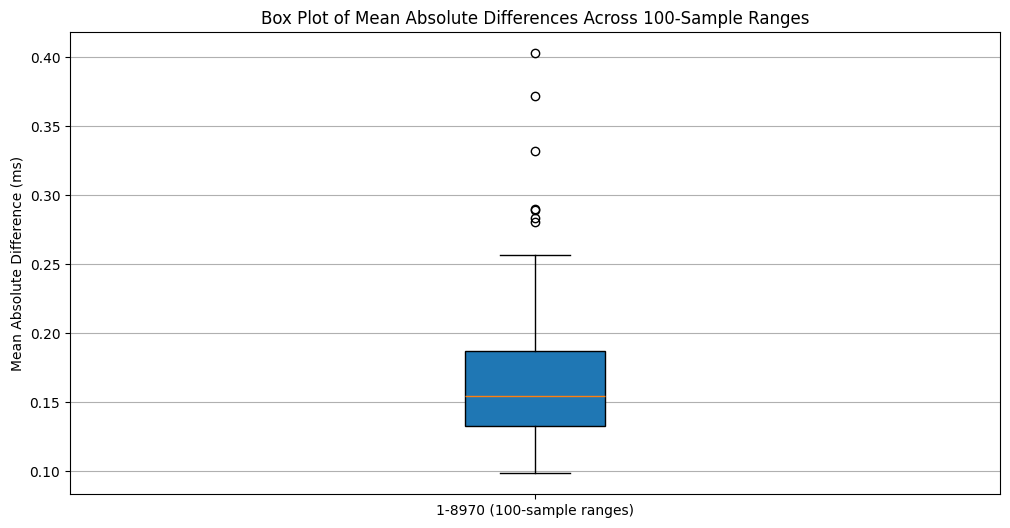

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    89.000000    89.000000      89.000000
mean   4401.000000  4500.000000       0.170989
std    2583.602137  2583.602137       0.058816
min       1.000000   100.000000       0.098699
25%    2201.000000  2300.000000       0.133097
50%    4401.000000  4500.000000       0.154455
75%    6601.000000  6700.000000       0.187261
max    8801.000000  8900.000000       0.402874


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_test) / (max_test - min_test)  # match test scale

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

sequence_length = 30
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], sequence_length, 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)


# -------------------------
# Custom Multi-Step Hybrid Prediction
# -------------------------
test_values = test_data['Normalized IP Delay'].values
future_steps = 10
predictions = []
actuals = []

i = 0
while i + sequence_length + future_steps <= len(test_values):
    # Step 1: Use actual values to build initial input
    input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
    
    block_preds = []
    current_seq = input_seq.copy()

    # Step 2: Predict next 10 steps recursively
    for _ in range(future_steps):
        pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
        next_val = pred.flatten()[0]
        block_preds.append(next_val)
        current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

    predictions.extend(block_preds)
    actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
    actuals.extend(actual_block)

    # Step 3: Move to the next block by shifting i by `future_steps`
    i += future_steps

# -------------------------
# Denormalize and Save
# -------------------------
preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

result_df = pd.DataFrame({
    'SN': range(1, len(actuals_denorm) + 1),
    'Actual IP Delay (ms)': actuals_denorm,
    'Predicted IP Delay (ms)': preds_denorm,
    'Absolute Difference (ms)': np.abs(actuals_denorm - preds_denorm)
})

# -------------------------
# Calculate Statistics for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(result_df) // range_size  # Adjusted to match prediction length
range_starts = [i * range_size + 1 for i in range(num_ranges)]
range_ends = [(i + 1) * range_size for i in range(num_ranges)]

mean_absolute_diff_range = []
quantile_90_absolute_diff_range = []
variance_absolute_diff_range = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        mean_absolute_diff_range.append(range_df['Absolute Difference (ms)'].mean())
        quantile_90_absolute_diff_range.append(range_df['Absolute Difference (ms)'].quantile(0.90))
        variance_absolute_diff_range.append(range_df['Absolute Difference (ms)'].var())

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Mean Absolute Difference (ms)': mean_absolute_diff_range
})
mean_df.to_csv('mean_imp_hybrid_range.csv', index=False)

quantile_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    '90th Quantile Absolute Difference (ms)': quantile_90_absolute_diff_range
})
quantile_df.to_csv('90thquantile_imp_hybrid_range.csv', index=False)

variance_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Variance Absolute Difference (ms²)': variance_absolute_diff_range
})
variance_df.to_csv('variance_imp_hybrid_range.csv', index=False)

print("Range-Based Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(mean_absolute_diff_range, patch_artist=True)
plt.title('Box Plot of Mean Absolute Differences Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], [f'1-{len(result_df)} (100-sample ranges)'])  # Updated to reflect actual data length
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Residual_Mean': mean_absolute_diff_range  # Using mean as the representative statistic for the range
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\692321823.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, patch_artist=True, labels=labels)


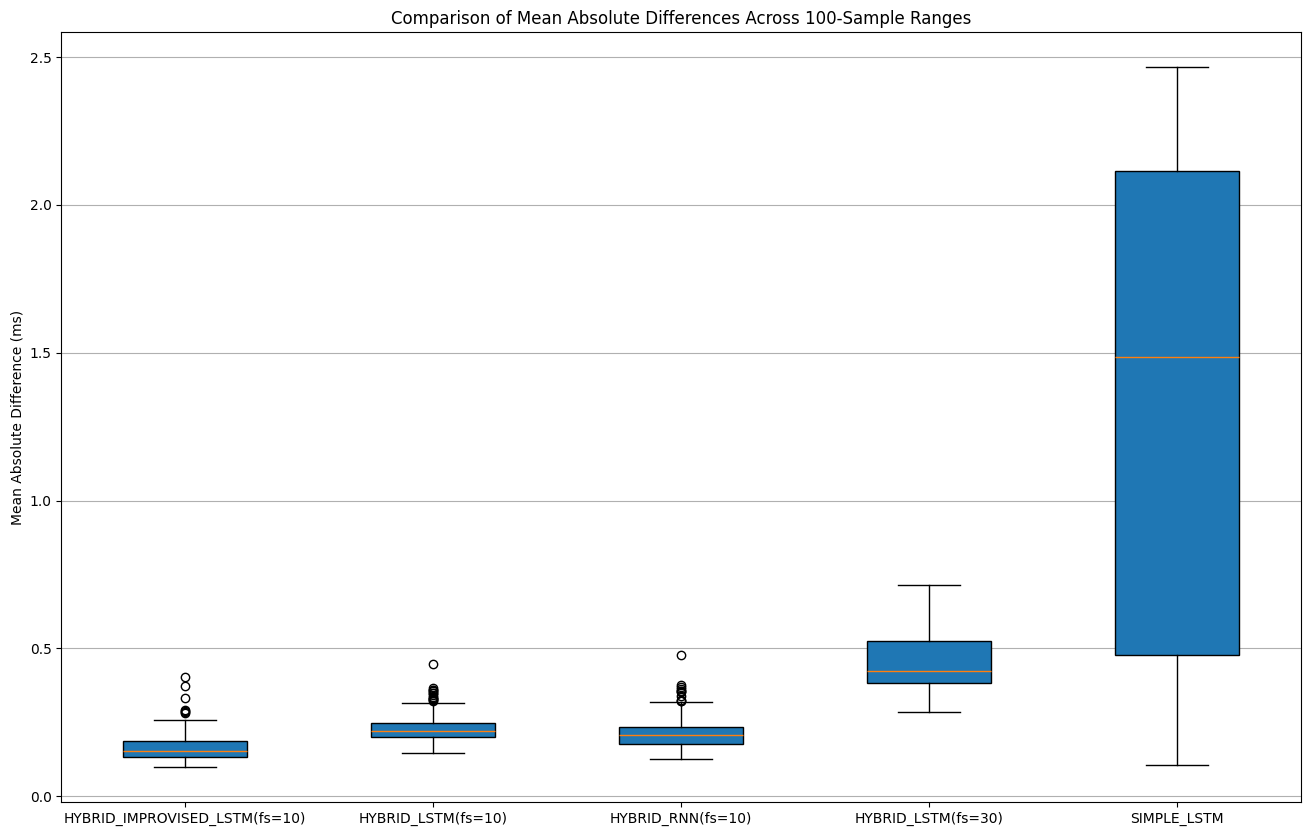

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from the four CSV files
imp_hybrid_lstm_df = pd.read_csv('mean_imp_hybrid_range.csv')
hybrid_lstm_df = pd.read_csv('mean_hybrid_range.csv')
hybrid_rnn_df = pd.read_csv('mean_hybrid_rnn_range.csv')
hybrid_lstm_30_df = pd.read_csv('mean_hybrid_30_range.csv')
multistep_lstm_df = pd.read_csv('mean_multistep_range.csv')

# Extract the mean absolute difference data
imp_hybrid_lstm_data = imp_hybrid_lstm_df['Mean Absolute Difference (ms)']
hybrid_lstm_data = hybrid_lstm_df['Mean Absolute Difference (ms)']
hybrid_rnn_data = hybrid_rnn_df['Mean Absolute Difference (ms)']
hybrid_lstm_30_data = hybrid_lstm_30_df['Mean Absolute Difference (ms)']
multistep_lstm_data = multistep_lstm_df['Mean Absolute Difference (ms)']

# Combine data into a list for box plot
data_to_plot = [imp_hybrid_lstm_data, hybrid_lstm_data, hybrid_rnn_data, hybrid_lstm_30_data, multistep_lstm_data]

# Labels for the box plot
labels = ['HYBRID_IMPROVISED_LSTM(fs=10)', 'HYBRID_LSTM(fs=10)', 'HYBRID_RNN(fs=10)', 'HYBRID_LSTM(fs=30)', 'SIMPLE_LSTM']

# Create the box plot
plt.figure(figsize=(16, 10))
plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
plt.title('Comparison of Mean Absolute Differences Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.grid(axis='y')
plt.show()

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\3966303706.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, patch_artist=True, labels=labels)


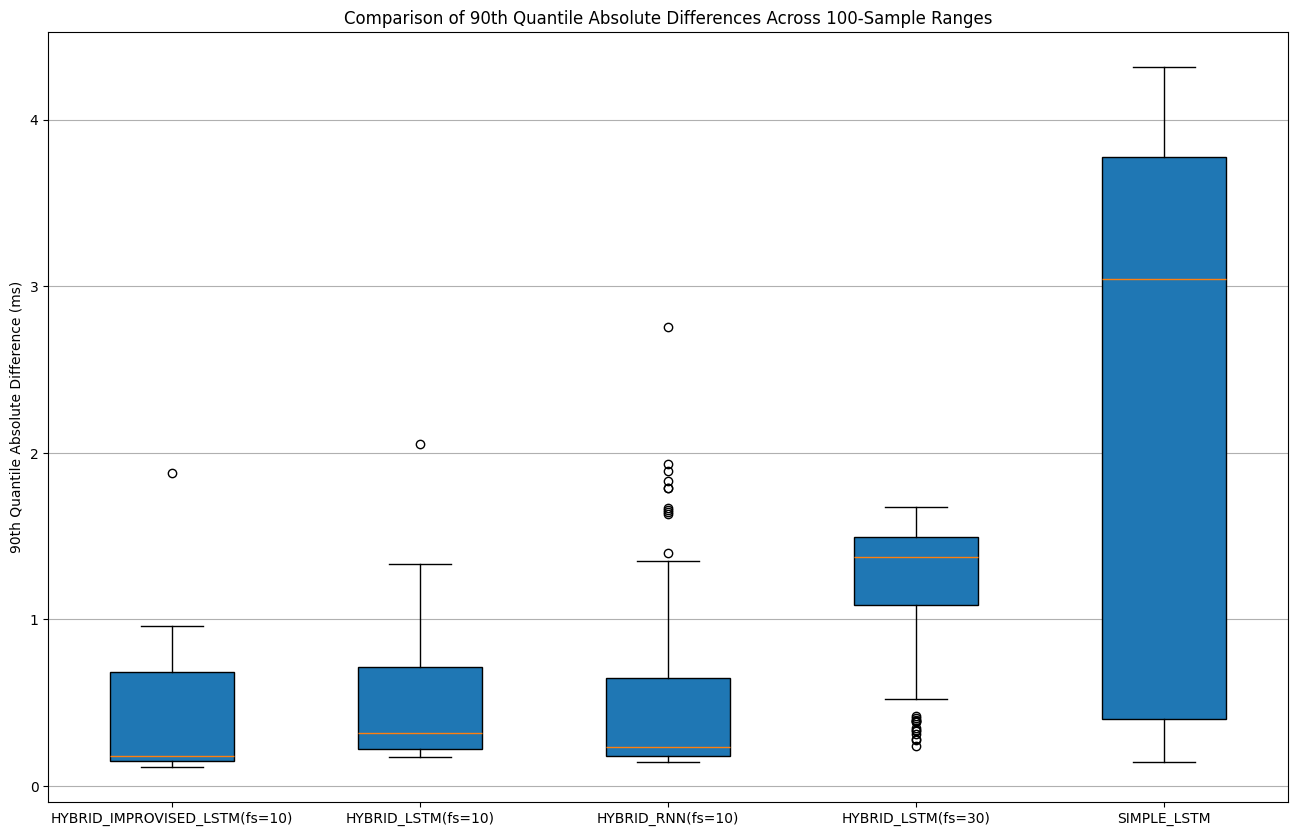

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from the four CSV files
imp_hybrid_lstm_df = pd.read_csv('90thquantile_imp_hybrid_range.csv')
hybrid_lstm_df = pd.read_csv('90thquantile_hybrid_range.csv')
hybrid_rnn_df = pd.read_csv('90thquantile_hybrid_rnn_range.csv')
hybrid_lstm_30_df = pd.read_csv('90thquantile_hybrid_30_range.csv')
multistep_lstm_df = pd.read_csv('90thquantile_multistep_range.csv')

# Extract the 90th quantile absolute difference data
imp_hybrid_lstm_data = imp_hybrid_lstm_df['90th Quantile Absolute Difference (ms)']
hybrid_lstm_data = hybrid_lstm_df['90th Quantile Absolute Difference (ms)']
hybrid_rnn_data = hybrid_rnn_df['90th Quantile Absolute Difference (ms)']
hybrid_lstm_30_data = hybrid_lstm_30_df['90th Quantile Absolute Difference (ms)']
multistep_lstm_data = multistep_lstm_df['90th Quantile Absolute Difference (ms)']

# Combine data into a list for box plot
data_to_plot = [imp_hybrid_lstm_data, hybrid_lstm_data, hybrid_rnn_data, hybrid_lstm_30_data, multistep_lstm_data]

# Labels for the box plot
labels = ['HYBRID_IMPROVISED_LSTM(fs=10)', 'HYBRID_LSTM(fs=10)', 'HYBRID_RNN(fs=10)', 'HYBRID_LSTM(fs=30)', 'SIMPLE_LSTM']

# Create the box plot
plt.figure(figsize=(16, 10))
plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
plt.title('Comparison of 90th Quantile Absolute Differences Across 100-Sample Ranges')
plt.ylabel('90th Quantile Absolute Difference (ms)')
plt.grid(axis='y')
plt.show()

C:\Users\karti\AppData\Local\Temp\ipykernel_18924\3774999864.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, patch_artist=True, labels=labels)


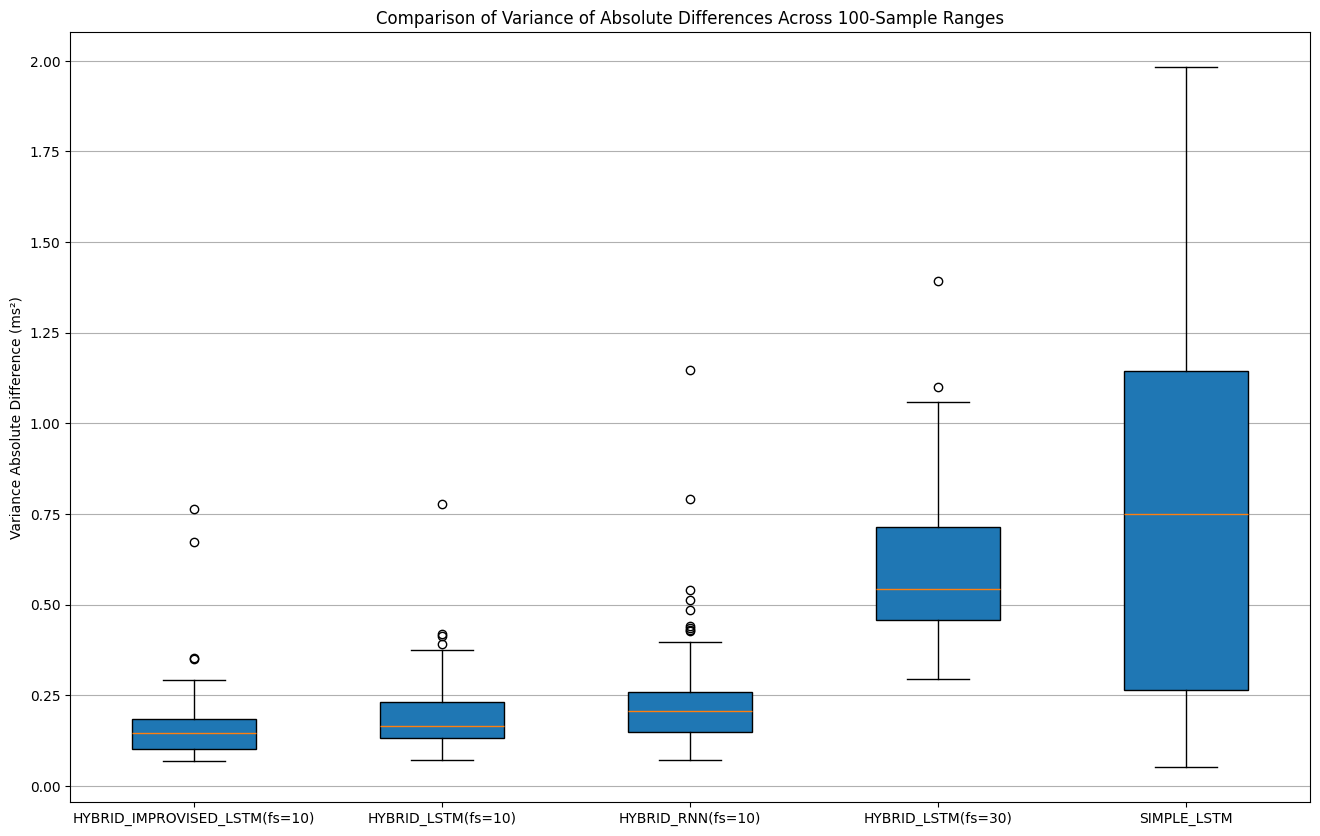

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from the four CSV files
imp_hybrid_lstm_df = pd.read_csv('variance_imp_hybrid_range.csv')
hybrid_lstm_df = pd.read_csv('variance_hybrid_range.csv')
hybrid_rnn_df = pd.read_csv('variance_hybrid_rnn_range.csv')
hybrid_lstm_30_df = pd.read_csv('variance_hybrid_30_range.csv')
multistep_lstm_df = pd.read_csv('variance_multistep_range.csv')

# Extract the variance absolute difference data
imp_hybrid_lstm_data = imp_hybrid_lstm_df['Variance Absolute Difference (ms²)']
hybrid_lstm_data = hybrid_lstm_df['Variance Absolute Difference (ms²)']
hybrid_rnn_data = hybrid_rnn_df['Variance Absolute Difference (ms²)']
hybrid_lstm_30_data = hybrid_lstm_30_df['Variance Absolute Difference (ms²)']
multistep_lstm_data = multistep_lstm_df['Variance Absolute Difference (ms²)']

# Combine data into a list for box plot
data_to_plot = [imp_hybrid_lstm_data, hybrid_lstm_data, hybrid_rnn_data, hybrid_lstm_30_data, multistep_lstm_data]

# Labels for the box plot
labels = ['HYBRID_IMPROVISED_LSTM(fs=10)','HYBRID_LSTM(fs=10)', 'HYBRID_RNN(fs=10)', 'HYBRID_LSTM(fs=30)', 'SIMPLE_LSTM']

# Create the box plot
plt.figure(figsize=(16, 10))
plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
plt.title('Comparison of Variance of Absolute Differences Across 100-Sample Ranges')
plt.ylabel('Variance Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

In [ ]:
model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(50, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='huber')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)
